Esse notebook contém as modelagens feitas para o projeto. Nele foram utilizadas as seguintes estratégias:
* Modelagem sem estratégias que levavam em conta o alto desbalanceamento do dataset, chamadas de modelagem simples
* Modelagem levando em consideração o desbalanceamento, porém somente no modelo, fazendo uso de uma proporção do desbalanceamento
* Modelagem levando em consideração o desbalanceamento utilizando uma técnica de oversampling chamada de SMOTE que gera dados sintéticos para tentar balancear os dados de treinamento

Modelos usados:
* Regressão logística
* Random Forest
* XGBoost

In [1]:
#- Imports e configurações
import warnings

# Bibliotecas especializadas
from scipy import stats
from sklearn.preprocessing import  StandardScaler


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    log_loss
  )
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE

#Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

#Salvar os modelos
import joblib

#Interpretabilidade
import shap



warnings.filterwarnings("ignore")

In [2]:
#Extraindo o dataset que irá ser utilizado
df = pd.read_csv("train_prep.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,0
1,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,0
2,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,0
3,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,0
4,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,0


In [3]:
X = df.drop(columns=['Class'])
y = df['Class']

In [72]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42)

In [73]:
smote = SMOTE(sampling_strategy='minority')
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [64]:
def salvar(model, params, nome):
  joblib.dump({
    "model": model,
    "params": params
  }, f"{nome}.pkl")
  print(f"Modelo salvo com sucesso no arquivo {nome}.pkl")


In [ ]:
def submit(model, nome, xgboost=False):
  # ==========================================================
  # 1️⃣ Carregar dataset de teste da competição
  # ==========================================================

  test_kaggle = pd.read_csv("test.csv")

  # Separe ID (ajuste o nome se necessário)
  ids = test_kaggle["id"]

  if xgboost:
    X_test_kaggle = xgb.DMatrix(test_kaggle.drop(columns=["id"]))
  else:
    X_test_kaggle = test_kaggle.drop(columns=["id"])
  # ==========================================================
  # 3️⃣ Gerar probabilidades
  # ==========================================================

  y_pred_prob_kaggle = best_model_bal.predict(X_test_kaggle)

  # ==========================================================
  # 4️⃣ Criar DataFrame de submissão
  # ==========================================================

  submission = pd.DataFrame({
      "id": ids,
      "target": y_pred_prob_kaggle  # ajuste nome da coluna conforme competição
  })

  # ==========================================================
  # 5️⃣ Salvar arquivo CSV
  # ==========================================================

  submission.to_csv(f"{nome}.csv", index=False)

  print(f"Arquivo {nome}.csv criado com sucesso!")

#XGboost

In [4]:
X_train_xgb = X_train
y_train_xgb = y_train
X_val_xgb = X_val
y_val_xgb = y_val
X_test_xgb = X_test
y_test_xgb = y_test

In [5]:
!pip install -U "ray[tune]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 8.9 MB/s eta 0:00:00


In [6]:
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune.integration.xgboost import TuneReportCheckpointCallback
import sklearn.metrics as metrics

import xgboost as xgb


In [7]:
ray.shutdown()
ray.init(ignore_reinit_error=True)


2026-02-21 15:59:46,479	INFO worker.py:2013 -- Started a local Ray instance.


Python version:,3.12.12
Ray version:,2.54.0


In [8]:
# Colocar dados no object store, pois se for colocar os dados direto da erro na
# execução por excesso de memória
X_train_ref = ray.put(X_train_xgb)
y_train_ref = ray.put(y_train_xgb)
X_val_ref = ray.put(X_val_xgb)
y_val_ref = ray.put(y_val_xgb)


In [58]:
# Espaço de Busca
search_space = {
    "max_depth": tune.randint(3, 7),
    "min_child_weight": tune.choice([5, 6, 7, 8, 9, 10]),
    "subsample": tune.uniform(0.6, 0.8),
    "colsample_bytree": tune.uniform(0.6, 0.8),
    "eta": tune.loguniform(1e-3, 0.05),
    "gamma": tune.uniform(1, 4),
    "reg_alpha": tune.uniform(1, 5),
    "reg_lambda": tune.uniform(5, 20),
    "objective": "binary:logistic",
    "eval_metric": ["logloss", "auc"],
    "tree_method": "hist"
}

# Scheduler (Early Pruning Inteligente)
scheduler = ASHAScheduler(
    metric="logloss", # Define metric here
    mode="min",       # Define mode here
    max_t=3000,
    grace_period=100,
    reduction_factor=2
)


##Funções Xgboost

In [56]:
def train_xgb(config, oversampling, scale_pos_weight):
  # Recupera dados do object store
  _X_train_original = ray.get(X_train_ref) # Use a temporary name to hold original data
  _y_train_original = ray.get(y_train_ref)
  X_val_local = ray.get(X_val_ref)
  y_val_local = ray.get(y_val_ref)

  config.update({
      "objective": "binary:logistic",
      "eval_metric": ["logloss", "auc"],
      "tree_method": "hist",
      "scale_pos_weight": scale_pos_weight,
  })

  # Initialize X_train_local and y_train_local
  X_train_local = _X_train_original
  y_train_local = _y_train_original

  #Aplicando oversampling com SMOTE
  if oversampling:
    X_train_local = ray.get(X_smote_ref) # Reassign to X_train_local if oversampling
    y_train_local = ray.get(y_smote_ref) # Reassign to y_train_local if oversampling


  dtrain = xgb.DMatrix(X_train_local, label=y_train_local)
  dval = xgb.DMatrix(X_val_local, label=y_val_local)

  #Treinamento
  xgb.train(
      config,
      dtrain,
      num_boost_round=3000,
      evals=[(dval, "eval")],
      early_stopping_rounds=100,
      verbose_eval=False,
      callbacks=[
          TuneReportCheckpointCallback(
              metrics={
                  "logloss": "eval-logloss",
                  "auc": "eval-auc"
              },
              frequency=1
          )
      ],
  )

def busca(train, search_space, scheduler):
  #Execução da busca
  tuner = tune.Tuner(
      train,
      tune_config=tune.TuneConfig(
          scheduler=scheduler,
          num_samples=30
      ),
      param_space=search_space
  )

  results = tuner.fit()
  return results

In [11]:
def avalicao_final(model, X_test, y_test):
  dtest = xgb.DMatrix(X_test, label=y_test)

  y_pred_prob = model.predict(dtest)

  print("\n========== RESULTADOS FINAIS ==========")
  print(f"LogLoss (Teste): {metrics.log_loss(y_test, y_pred_prob):.6f}")
  print(f"ROC-AUC (Teste): {metrics.roc_auc_score(y_test, y_pred_prob):.6f}")

In [12]:
def interpretar_shap_xgb(
    model,
    X,
    instance_index=None,
    plot_summary=True,
    plot_bar=True,
    plot_local=False
):

    # Criando explainer específico para árvore
    explainer = shap.TreeExplainer(model)

    # Cálculo dos valores SHAP
    shap_values = explainer.shap_values(X)

    print("SHAP calculado com sucesso.")

    # ==========================
    # 📊 Summary Plot (Global)
    # ==========================
    if plot_summary:
        plt.figure()
        shap.summary_plot(shap_values, X)

    # ==========================
    # 📊 Importância média (Bar)
    # ==========================
    if plot_bar:
        plt.figure()
        shap.summary_plot(shap_values, X, plot_type="bar")

    # ==========================
    # 🔍 Explicação Local
    # ==========================
    if plot_local and instance_index is not None:
        print(f"\nExplicação local para instância {instance_index}")

        shap.initjs()
        shap.force_plot(
            explainer.expected_value,
            shap_values[instance_index],
            X.iloc[instance_index]
        )

##Modelagem simples

In [ ]:
# Treinamento do Modelo
results_xbg_simples = busca(tune.with_parameters(train_xgb, oversampling=False, scale_pos_weight=None), search_space=search_space, scheduler=scheduler)

# Melhor Resultado
best_result_simples = results_xbg_simples.get_best_result(metric="logloss", mode="min")

#Melhor modelo
best_model_simples = TuneReportCheckpointCallback.get_model(best_result_simples.checkpoint)

print("Melhores parâmetros encontrados:")
print(best_result_simples.config)

# Avaliação no conjunto de teste
avalicao_final(best_model_simples, X_test_xgb, y_test_xgb)

+------------------------------------------------------------------+
| Configuration for experiment     train_xgb_2026-02-20_22-29-23   |
+------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator           |
| Scheduler                        AsyncHyperBandScheduler         |
| Number of trials                 30                              |
+------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_xgb_2026-02-20_22-29-23
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-02-20_22-28-45_813687_543/artifacts/2026-02-20_22-29-23/train_xgb_2026-02-20_22-29-23/driver_artifacts`

Trial status: 30 PENDING
Current time: 2026-02-20 22:29:24. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------------------------------------------

(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000000)
(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000001)
(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000081) [repeated 174x across cluster]



Trial train_xgb_9b68a_00001 completed after 117 iterations at 2026-02-20 22:29:47. Total running time: 24s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00001 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000116 |
| time_this_iter_s                                 0.06212 |
| time_total_s                                     7.29764 |
| training_iteration                                   117 |
| auc                                              0.96158 |
| logloss                                          0.00574 |
+----------------------------------------------------------+


(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000135) [repeated 77x across cluster]



Trial status: 1 RUNNING | 1 TERMINATED | 28 PENDING
Current time: 2026-02-20 22:29:54. Total running time: 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00230936924689217 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      logloss 

(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000214) [repeated 79x across cluster]
(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000273) [repeated 59x across cluster]



Trial train_xgb_9b68a_00002 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00002 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.76347 |
| eta                                               0.00203 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                              3.7211 |
| max_depth                                               4 |
| min_child_weight                                        6 |
| objective                                 binary:logistic |
| reg_alpha                                         1.17209 |
| reg_lambda                                       14.57865 |
| subsample                                         0.67722 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000353) [repeated 80x across cluster]
(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000415) [repeated 115x across cluster]



Trial train_xgb_9b68a_00002 completed after 76 iterations at 2026-02-20 22:30:13. Total running time: 49s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00002 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000075 |
| time_this_iter_s                                 0.11497 |
| time_total_s                                     6.22188 |
| training_iteration                                    76 |
| auc                                              0.95799 |
| logloss                                          0.01087 |
+----------------------------------------------------------+


(train_xgb pid=91581) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00000_0_colsample_bytree=0.6295,eta=0.0471,gamma=1.5562,max_depth=3,min_child_weight=5,reg_alpha=2.5765,reg_lambda_2026-02-20_22-29-23/checkpoint_000442) [repeated 50x across cluster]



Trial train_xgb_9b68a_00000 completed after 460 iterations at 2026-02-20 22:30:20. Total running time: 57s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00000 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000459 |
| time_this_iter_s                                 0.04349 |
| time_total_s                                      35.469 |
| training_iteration                                   460 |
| auc                                              0.97826 |
| logloss                                          0.00216 |
+----------------------------------------------------------+

Trial status: 3 TERMINATED | 27 PENDING
Current time: 2026-02-20 22:30:24. Total running time: 1min 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.64

(train_xgb pid=92000) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00003_3_colsample_bytree=0.7623,eta=0.0057,gamma=2.4969,max_depth=3,min_child_weight=7,reg_alpha=3.9700,reg_lambda_2026-02-20_22-29-23/checkpoint_000001) [repeated 19x across cluster]



Trial train_xgb_9b68a_00003 completed after 100 iterations at 2026-02-20 22:30:45. Total running time: 1min 21s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00003 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.03358 |
| time_total_s                                      5.0658 |
| training_iteration                                   100 |
| auc                                              0.95755 |
| logloss                                          0.00624 |
+----------------------------------------------------------+


(train_xgb pid=92041) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00004_4_colsample_bytree=0.7750,eta=0.0242,gamma=3.3074,max_depth=4,min_child_weight=6,reg_alpha=3.5827,reg_lambda_2026-02-20_22-29-23/checkpoint_000105) [repeated 204x across cluster]
(train_xgb pid=92041) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00004_4_colsample_bytree=0.7750,eta=0.0242,gamma=3.3074,max_depth=4,min_child_weight=6,reg_alpha=3.5827,reg_lambda_2026-02-20_22-29-23/checkpoint_000131) [repeated 26x across cluster]



Trial status: 4 TERMINATED | 1 RUNNING | 25 PENDING
Current time: 2026-02-20 22:30:54. Total running time: 1min 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      log

(train_xgb pid=92252) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00005_5_colsample_bytree=0.7340,eta=0.0011,gamma=3.7652,max_depth=3,min_child_weight=10,reg_alpha=2.9201,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 69x across cluster]



Trial train_xgb_9b68a_00006 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00006 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.64186 |
| eta                                               0.00423 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             3.62862 |
| max_depth                                               4 |
| min_child_weight                                       10 |
| objective                                 binary:logistic |
| reg_alpha                                           1.367 |
| reg_lambda                                       16.84392 |
| subsample                                         0.64392 |
| tree_method                                          hist |
+-----------------------------------------------------------+

Trial train_

(train_xgb pid=92351) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00006_6_colsample_bytree=0.6419,eta=0.0042,gamma=3.6286,max_depth=4,min_child_weight=10,reg_alpha=1.3670,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 100x across cluster]
(train_xgb pid=92351) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00006_6_colsample_bytree=0.6419,eta=0.0042,gamma=3.6286,max_depth=4,min_child_weight=10,reg_alpha=1.3670,reg_lambd_2026-02-20_22-29-23/checkpoint_000053) [repeated 53x across cluster]



Trial train_xgb_9b68a_00006 completed after 100 iterations at 2026-02-20 22:31:23. Total running time: 2min 0s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00006 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.03177 |
| time_total_s                                     9.51655 |
| training_iteration                                   100 |
| auc                                              0.97341 |
| logloss                                          0.00945 |
+----------------------------------------------------------+

Trial status: 7 TERMINATED | 23 PENDING
Current time: 2026-02-20 22:31:24. Total running time: 2min 0s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 

(train_xgb pid=92507) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00007_7_colsample_bytree=0.6082,eta=0.0012,gamma=2.1593,max_depth=3,min_child_weight=10,reg_alpha=2.1843,reg_lambd_2026-02-20_22-29-23/checkpoint_000001) [repeated 48x across cluster]



Trial train_xgb_9b68a_00007 completed after 62 iterations at 2026-02-20 22:31:40. Total running time: 2min 16s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00007 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000061 |
| time_this_iter_s                                 0.03226 |
| time_total_s                                     3.50839 |
| training_iteration                                    62 |
| auc                                              0.95443 |
| logloss                                          0.01175 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00008 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00008 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=92606) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00008_8_colsample_bytree=0.7241,eta=0.0052,gamma=2.5641,max_depth=4,min_child_weight=8,reg_alpha=4.4774,reg_lambda_2026-02-20_22-29-23/checkpoint_000000) [repeated 61x across cluster]
(train_xgb pid=92606) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00008_8_colsample_bytree=0.7241,eta=0.0052,gamma=2.5641,max_depth=4,min_child_weight=8,reg_alpha=4.4774,reg_lambda_2026-02-20_22-29-23/checkpoint_000037) [repeated 37x across cluster]



Trial train_xgb_9b68a_00008 completed after 100 iterations at 2026-02-20 22:31:51. Total running time: 2min 28s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00008 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.04138 |
| time_total_s                                     9.20608 |
| training_iteration                                   100 |
| auc                                              0.96095 |
| logloss                                          0.00717 |
+----------------------------------------------------------+

Trial status: 9 TERMINATED | 21 PENDING
Current time: 2026-02-20 22:31:54. Total running time: 2min 30s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample'

(train_xgb pid=92755) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00009_9_colsample_bytree=0.6282,eta=0.0286,gamma=1.5977,max_depth=4,min_child_weight=10,reg_alpha=3.4517,reg_lambd_2026-02-20_22-29-23/checkpoint_000002) [repeated 65x across cluster]



Trial train_xgb_9b68a_00010 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00010 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.79718 |
| eta                                               0.02127 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                              1.9248 |
| max_depth                                               4 |
| min_child_weight                                        8 |
| objective                                 binary:logistic |
| reg_alpha                                         3.73357 |
| reg_lambda                                        8.41817 |
| subsample                                          0.7584 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=92755) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00009_9_colsample_bytree=0.6282,eta=0.0286,gamma=1.5977,max_depth=4,min_child_weight=10,reg_alpha=3.4517,reg_lambd_2026-02-20_22-29-23/checkpoint_000110) [repeated 108x across cluster]
(train_xgb pid=92755) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00009_9_colsample_bytree=0.6282,eta=0.0286,gamma=1.5977,max_depth=4,min_child_weight=10,reg_alpha=3.4517,reg_lambd_2026-02-20_22-29-23/checkpoint_000175) [repeated 135x across cluster]



Trial train_xgb_9b68a_00009 completed after 200 iterations at 2026-02-20 22:32:17. Total running time: 2min 54s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00009 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000199 |
| time_this_iter_s                                 0.04631 |
| time_total_s                                    11.73399 |
| training_iteration                                   200 |
| auc                                              0.97613 |
| logloss                                          0.00242 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00010 completed after 117 iterations at 2026-02-20 22:32:18. Total running time: 2min 55s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00010 result                       |
+-----------------------------------------

(train_xgb pid=93048) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00011_11_colsample_bytree=0.6892,eta=0.0226,gamma=1.7135,max_depth=3,min_child_weight=6,reg_alpha=3.7127,reg_lambd_2026-02-20_22-29-23/checkpoint_000001) [repeated 73x across cluster]



Trial train_xgb_9b68a_00011 completed after 57 iterations at 2026-02-20 22:32:42. Total running time: 3min 19s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00011 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000056 |
| time_this_iter_s                                 0.05995 |
| time_total_s                                     3.89647 |
| training_iteration                                    57 |
| auc                                              0.96403 |
| logloss                                          0.00427 |
+----------------------------------------------------------+


(train_xgb pid=93079) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00012_12_colsample_bytree=0.7614,eta=0.0183,gamma=1.9996,max_depth=4,min_child_weight=10,reg_alpha=1.5827,reg_lamb_2026-02-20_22-29-23/checkpoint_000060) [repeated 116x across cluster]
(train_xgb pid=93079) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00012_12_colsample_bytree=0.7614,eta=0.0183,gamma=1.9996,max_depth=4,min_child_weight=10,reg_alpha=1.5827,reg_lamb_2026-02-20_22-29-23/checkpoint_000118) [repeated 58x across cluster]



Trial status: 12 TERMINATED | 1 RUNNING | 17 PENDING
Current time: 2026-02-20 22:32:54. Total running time: 3min 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      lo

(train_xgb pid=93079) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00012_12_colsample_bytree=0.7614,eta=0.0183,gamma=1.9996,max_depth=4,min_child_weight=10,reg_alpha=1.5827,reg_lamb_2026-02-20_22-29-23/checkpoint_000199) [repeated 81x across cluster]



Trial train_xgb_9b68a_00013 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00013 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.64725 |
| eta                                               0.00814 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             1.83051 |
| max_depth                                               3 |
| min_child_weight                                        5 |
| objective                                 binary:logistic |
| reg_alpha                                         3.87882 |
| reg_lambda                                       16.38208 |
| subsample                                         0.62113 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=93289) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00013_13_colsample_bytree=0.6473,eta=0.0081,gamma=1.8305,max_depth=3,min_child_weight=5,reg_alpha=3.8788,reg_lambd_2026-02-20_22-29-23/checkpoint_000000)
(train_xgb pid=93289) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00013_13_colsample_bytree=0.6473,eta=0.0081,gamma=1.8305,max_depth=3,min_child_weight=5,reg_alpha=3.8788,reg_lambd_2026-02-20_22-29-23/checkpoint_000001)
(train_xgb pid=93289) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00013_13_colsample_bytree=0.6473,eta=0.0081,gamma=1.8305,max_depth=3,min_child_weight=5,reg_alpha=3.8788,reg_lambd_2026-02-20_22-29-23/checkpoint_000002)
(train_xgb pid=93289) Checkpoint successfully created at: Checkpoint(f


Trial train_xgb_9b68a_00013 completed after 59 iterations at 2026-02-20 22:33:09. Total running time: 3min 46s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00013 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000058 |
| time_this_iter_s                                 0.03781 |
| time_total_s                                     4.13265 |
| training_iteration                                    59 |
| auc                                              0.96141 |
| logloss                                           0.0085 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00014 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00014 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=93405) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00014_14_colsample_bytree=0.6236,eta=0.0014,gamma=2.2500,max_depth=4,min_child_weight=7,reg_alpha=1.3464,reg_lambd_2026-02-20_22-29-23/checkpoint_000002) [repeated 3x across cluster]



Trial train_xgb_9b68a_00014 completed after 55 iterations at 2026-02-20 22:33:22. Total running time: 3min 59s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00014 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000054 |
| time_this_iter_s                                 0.03473 |
| time_total_s                                     3.78561 |
| training_iteration                                    55 |
| auc                                              0.95636 |
| logloss                                          0.01155 |
+----------------------------------------------------------+

Trial status: 15 TERMINATED | 15 PENDING
Current time: 2026-02-20 22:33:24. Total running time: 4min 1s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample':

(train_xgb pid=93532) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00015_15_colsample_bytree=0.7930,eta=0.0124,gamma=1.5439,max_depth=3,min_child_weight=10,reg_alpha=4.4357,reg_lamb_2026-02-20_22-29-23/checkpoint_000000) [repeated 53x across cluster]
(train_xgb pid=93532) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00015_15_colsample_bytree=0.7930,eta=0.0124,gamma=1.5439,max_depth=3,min_child_weight=10,reg_alpha=4.4357,reg_lamb_2026-02-20_22-29-23/checkpoint_000110) [repeated 110x across cluster]



Trial train_xgb_9b68a_00016 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00016 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.77405 |
| eta                                               0.02985 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                              1.6821 |
| max_depth                                               3 |
| min_child_weight                                       10 |
| objective                                 binary:logistic |
| reg_alpha                                         3.46546 |
| reg_lambda                                       11.57562 |
| subsample                                         0.77728 |
| tree_method                                          hist |
+-----------------------------------------------------------+

Trial train_

(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000000) [repeated 15x across cluster]
(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000088) [repeated 88x across cluster]



Trial status: 16 TERMINATED | 1 RUNNING | 13 PENDING
Current time: 2026-02-20 22:33:54. Total running time: 4min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      lo

(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000165) [repeated 77x across cluster]



Trial train_xgb_9b68a_00017 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00017 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.75032 |
| eta                                               0.00902 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             2.08169 |
| max_depth                                               4 |
| min_child_weight                                        8 |
| objective                                 binary:logistic |
| reg_alpha                                         4.65392 |
| reg_lambda                                       13.85566 |
| subsample                                         0.69724 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000227) [repeated 62x across cluster]
(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000311) [repeated 157x across cluster]



Trial train_xgb_9b68a_00017 completed after 100 iterations at 2026-02-20 22:34:07. Total running time: 4min 44s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00017 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.06159 |
| time_total_s                                     5.62727 |
| training_iteration                                   100 |
| auc                                              0.96349 |
| logloss                                          0.00559 |
+----------------------------------------------------------+


(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000354) [repeated 70x across cluster]
(train_xgb pid=93651) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00016_16_colsample_bytree=0.7741,eta=0.0299,gamma=1.6821,max_depth=3,min_child_weight=10,reg_alpha=3.4655,reg_lamb_2026-02-20_22-29-23/checkpoint_000394) [repeated 40x across cluster]



Trial train_xgb_9b68a_00016 completed after 400 iterations at 2026-02-20 22:34:16. Total running time: 4min 53s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00016 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000399 |
| time_this_iter_s                                 0.05714 |
| time_total_s                                    30.62851 |
| training_iteration                                   400 |
| auc                                              0.97643 |
| logloss                                          0.00228 |
+----------------------------------------------------------+

Trial status: 18 TERMINATED | 12 PENDING
Current time: 2026-02-20 22:34:24. Total running time: 5min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample'

(train_xgb pid=93986) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00018_18_colsample_bytree=0.6447,eta=0.0048,gamma=2.3252,max_depth=4,min_child_weight=8,reg_alpha=4.3492,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 6x across cluster]



Trial train_xgb_9b68a_00018 completed after 55 iterations at 2026-02-20 22:34:34. Total running time: 5min 10s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00018 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000054 |
| time_this_iter_s                                 0.03301 |
| time_total_s                                     3.33463 |
| training_iteration                                    55 |
| auc                                              0.96063 |
| logloss                                           0.0098 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00019 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00019 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=94080) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00019_19_colsample_bytree=0.7022,eta=0.0041,gamma=1.5963,max_depth=4,min_child_weight=10,reg_alpha=2.1425,reg_lamb_2026-02-20_22-29-23/checkpoint_000002) [repeated 57x across cluster]
(train_xgb pid=94080) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00019_19_colsample_bytree=0.7022,eta=0.0041,gamma=1.5963,max_depth=4,min_child_weight=10,reg_alpha=2.1425,reg_lamb_2026-02-20_22-29-23/checkpoint_000042) [repeated 40x across cluster]



Trial train_xgb_9b68a_00019 completed after 65 iterations at 2026-02-20 22:34:44. Total running time: 5min 21s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00019 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000064 |
| time_this_iter_s                                 0.04062 |
| time_total_s                                     8.71442 |
| training_iteration                                    65 |
| auc                                              0.95465 |
| logloss                                          0.01007 |
+----------------------------------------------------------+

Trial status: 20 TERMINATED | 10 PENDING
Current time: 2026-02-20 22:34:54. Total running time: 5min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample'

(train_xgb pid=94231) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00020_20_colsample_bytree=0.6929,eta=0.0021,gamma=2.1294,max_depth=3,min_child_weight=8,reg_alpha=1.8523,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 23x across cluster]



Trial train_xgb_9b68a_00020 completed after 54 iterations at 2026-02-20 22:35:01. Total running time: 5min 37s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00020 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000053 |
| time_this_iter_s                                 0.03081 |
| time_total_s                                     5.11485 |
| training_iteration                                    54 |
| auc                                              0.94903 |
| logloss                                          0.01089 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00021 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00021 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=94334) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00021_21_colsample_bytree=0.6196,eta=0.0030,gamma=1.6504,max_depth=4,min_child_weight=10,reg_alpha=2.9454,reg_lamb_2026-02-20_22-29-23/checkpoint_000000) [repeated 54x across cluster]
(train_xgb pid=94334) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00021_21_colsample_bytree=0.6196,eta=0.0030,gamma=1.6504,max_depth=4,min_child_weight=10,reg_alpha=2.9454,reg_lamb_2026-02-20_22-29-23/checkpoint_000039) [repeated 39x across cluster]



Trial train_xgb_9b68a_00021 completed after 100 iterations at 2026-02-20 22:35:14. Total running time: 5min 51s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00021 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.03205 |
| time_total_s                                     9.38997 |
| training_iteration                                   100 |
| auc                                              0.96642 |
| logloss                                          0.00938 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00022 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00022 config                        |
+-----------------------------------------------------------+
| colsample_bytree                

(train_xgb pid=94471) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00022_22_colsample_bytree=0.7951,eta=0.0107,gamma=3.8728,max_depth=3,min_child_weight=7,reg_alpha=2.1984,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 61x across cluster]



Trial status: 22 TERMINATED | 1 RUNNING | 7 PENDING
Current time: 2026-02-20 22:35:24. Total running time: 6min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      logl

(train_xgb pid=94471) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00022_22_colsample_bytree=0.7951,eta=0.0107,gamma=3.8728,max_depth=3,min_child_weight=7,reg_alpha=2.1984,reg_lambd_2026-02-20_22-29-23/checkpoint_000037) [repeated 37x across cluster]



Trial train_xgb_9b68a_00022 completed after 100 iterations at 2026-02-20 22:35:29. Total running time: 6min 6s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00022 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.03337 |
| time_total_s                                     8.69635 |
| training_iteration                                   100 |
| auc                                              0.95742 |
| logloss                                          0.00535 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00023 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00023 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=94595) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00023_23_colsample_bytree=0.6921,eta=0.0098,gamma=3.3778,max_depth=3,min_child_weight=9,reg_alpha=1.1695,reg_lambd_2026-02-20_22-29-23/checkpoint_000001) [repeated 64x across cluster]
(train_xgb pid=94595) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00023_23_colsample_bytree=0.6921,eta=0.0098,gamma=3.3778,max_depth=3,min_child_weight=9,reg_alpha=1.1695,reg_lambd_2026-02-20_22-29-23/checkpoint_000048) [repeated 47x across cluster]



Trial train_xgb_9b68a_00023 completed after 80 iterations at 2026-02-20 22:35:42. Total running time: 6min 18s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00023 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000079 |
| time_this_iter_s                                  0.0323 |
| time_total_s                                     7.79788 |
| training_iteration                                    80 |
| auc                                              0.96013 |
| logloss                                          0.00531 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00024 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00024 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=94729) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00024_24_colsample_bytree=0.6268,eta=0.0020,gamma=3.3604,max_depth=3,min_child_weight=6,reg_alpha=4.2514,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 32x across cluster]



Trial status: 24 TERMINATED | 1 RUNNING | 5 PENDING
Current time: 2026-02-20 22:35:54. Total running time: 6min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      log

(train_xgb pid=94729) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00024_24_colsample_bytree=0.6268,eta=0.0020,gamma=3.3604,max_depth=3,min_child_weight=6,reg_alpha=4.2514,reg_lambd_2026-02-20_22-29-23/checkpoint_000049) [repeated 49x across cluster]



Trial train_xgb_9b68a_00024 completed after 55 iterations at 2026-02-20 22:35:55. Total running time: 6min 32s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00024 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000054 |
| time_this_iter_s                                 0.06879 |
| time_total_s                                     7.06813 |
| training_iteration                                    55 |
| auc                                              0.95775 |
| logloss                                          0.01134 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00025 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00025 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=94849) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00025_25_colsample_bytree=0.6583,eta=0.0104,gamma=3.9023,max_depth=4,min_child_weight=5,reg_alpha=3.2044,reg_lambd_2026-02-20_22-29-23/checkpoint_000002) [repeated 8x across cluster]



Trial train_xgb_9b68a_00025 completed after 54 iterations at 2026-02-20 22:36:09. Total running time: 6min 45s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00025 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000053 |
| time_this_iter_s                                 0.03936 |
| time_total_s                                     6.27982 |
| training_iteration                                    54 |
| auc                                               0.9568 |
| logloss                                          0.00544 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00026 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00026 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=94972) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00026_26_colsample_bytree=0.6930,eta=0.0010,gamma=3.7901,max_depth=3,min_child_weight=5,reg_alpha=2.2071,reg_lambd_2026-02-20_22-29-23/checkpoint_000002) [repeated 54x across cluster]
(train_xgb pid=94972) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00026_26_colsample_bytree=0.6930,eta=0.0010,gamma=3.7901,max_depth=3,min_child_weight=5,reg_alpha=2.2071,reg_lambd_2026-02-20_22-29-23/checkpoint_000073) [repeated 71x across cluster]



Trial status: 26 TERMINATED | 1 RUNNING | 3 PENDING
Current time: 2026-02-20 22:36:24. Total running time: 7min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6474090367937959, 'colsample_bytree': 0.6294970843871099, 'eta': 0.047081239474855395, 'gamma': 1.5561707079551523, 'reg_alpha': 2.5764640560046943, 'reg_lambda': 11.415855044399308, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)      logl

(train_xgb pid=95093) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00027_27_colsample_bytree=0.6261,eta=0.0018,gamma=1.5880,max_depth=3,min_child_weight=6,reg_alpha=4.0717,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 27x across cluster]



Trial train_xgb_9b68a_00027 completed after 55 iterations at 2026-02-20 22:36:33. Total running time: 7min 10s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00027 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000054 |
| time_this_iter_s                                 0.03123 |
| time_total_s                                     4.21749 |
| training_iteration                                    55 |
| auc                                              0.95609 |
| logloss                                          0.01106 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00028 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00028 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=95237) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00028_28_colsample_bytree=0.7670,eta=0.0130,gamma=3.6870,max_depth=4,min_child_weight=5,reg_alpha=4.4457,reg_lambd_2026-02-20_22-29-23/checkpoint_000000) [repeated 55x across cluster]



Trial train_xgb_9b68a_00028 completed after 71 iterations at 2026-02-20 22:36:51. Total running time: 7min 28s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00028 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000070 |
| time_this_iter_s                                 0.07889 |
| time_total_s                                     5.00314 |
| training_iteration                                    71 |
| auc                                              0.95709 |
| logloss                                          0.00508 |
+----------------------------------------------------------+

Trial train_xgb_9b68a_00029 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_9b68a_00029 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=95340) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-20_22-29-23/train_xgb_9b68a_00029_29_colsample_bytree=0.6209,eta=0.0107,gamma=2.4084,max_depth=3,min_child_weight=6,reg_alpha=1.7564,reg_lambd_2026-02-20_22-29-23/checkpoint_000002) [repeated 73x across cluster]
2026-02-20 22:36:57,516	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_xgb_2026-02-20_22-29-23' in 0.0817s.



Trial train_xgb_9b68a_00029 completed after 55 iterations at 2026-02-20 22:36:57. Total running time: 7min 33s
+----------------------------------------------------------+
| Trial train_xgb_9b68a_00029 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000054 |
| time_this_iter_s                                 0.02215 |
| time_total_s                                     2.45889 |
| training_iteration                                    55 |
| auc                                              0.95574 |
| logloss                                          0.00516 |
+----------------------------------------------------------+

Trial status: 30 TERMINATED
Current time: 2026-02-20 22:36:57. Total running time: 7min 34s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: 9b68a_00000 with logloss=0.00216243561538731 and params={'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.647409036

In [67]:
salvar(best_model_simples, best_result_simples.config, 'xgb_simples')


Modelo salvo com sucesso no arquivo xgb_simples.pkl


SHAP calculado com sucesso.


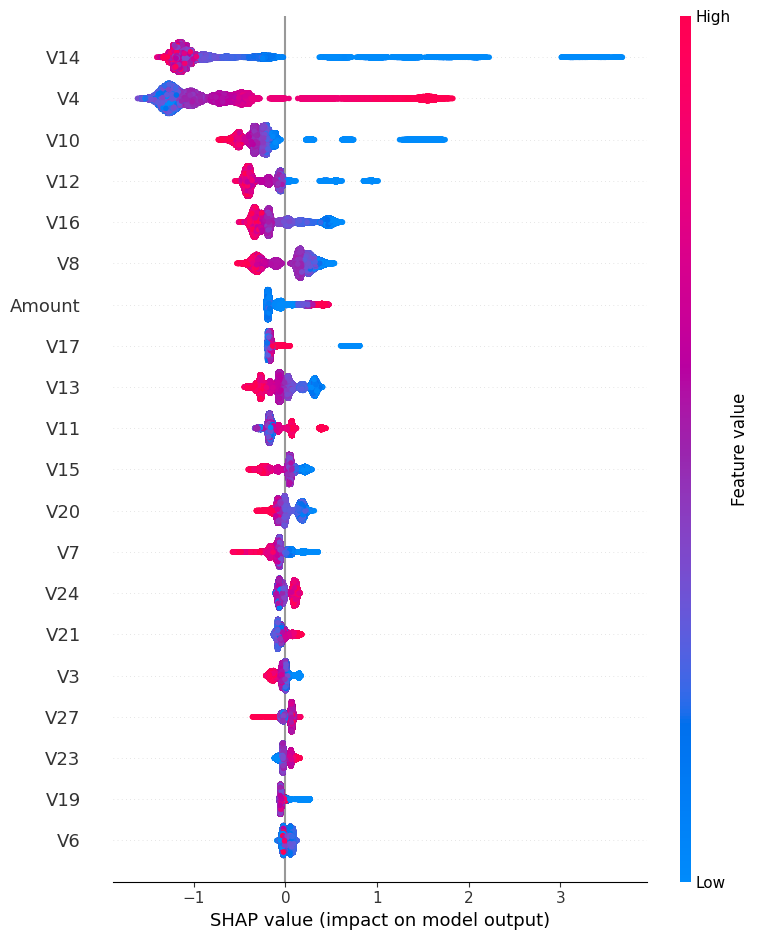

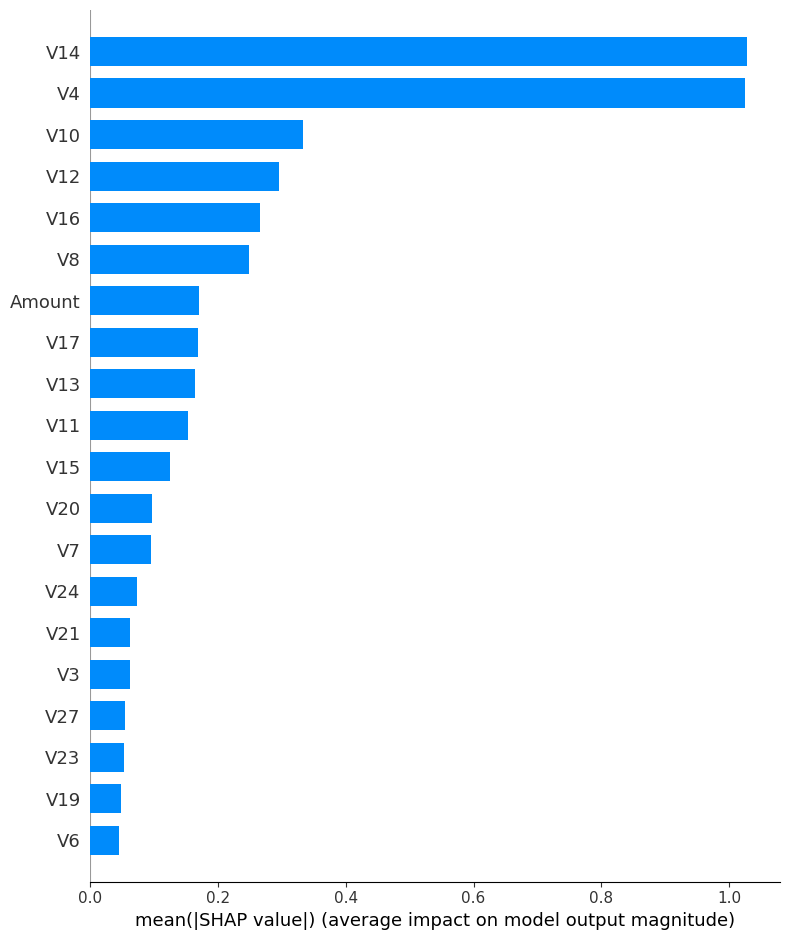

In [ ]:
interpretar_shap_xgb(best_model_simples, X)

##Modelagem com balanceamento do modelo

In [ ]:
#Cálculo do scale_pos_weight
y_train_array = y_train_xgb.values if hasattr(y_train_xgb, "values") else y_train_xgb
prop = (y_train_array == 0).sum() / (y_train_array == 1).sum()

# Treinamento do Modelo
results_xbg_bal = busca(tune.with_parameters(train_xgb, oversampling=False, scale_pos_weight=prop), search_space=search_space, scheduler=scheduler)

# Melhor modelo
best_result_bal = results_xbg_bal.get_best_result(metric="logloss", mode="min")

best_model_bal = TuneReportCheckpointCallback.get_model(best_result_bal.checkpoint)

print("Melhores parâmetros encontrados:")
print(best_result_bal.config)

#Avaliação final
avalicao_final(best_model_bal, X_test_xgb, y_test_xgb)


+--------------------------------------------------------------------------+
| Configuration for experiment     train_fraud_model_2026-02-20_13-48-40   |
+--------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                   |
| Scheduler                        AsyncHyperBandScheduler                 |
| Number of trials                 30                                      |
+--------------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_fraud_model_2026-02-20_13-48-40
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-02-20_13-48-00_916229_237/artifacts/2026-02-20_13-48-40/train_fraud_model_2026-02-20_13-48-40/driver_artifacts`

Trial status: 30 PENDING
Current time: 2026-02-20 13:48:48. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+-------------------------------------------

(train_fraud_model pid=25724) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00000_0_colsample_bytree=0.7130,eta=0.0010,gamma=1.3651,max_depth=4,min_child_weight=8,reg_alpha=4.9448,re_2026-02-20_13-48-47/checkpoint_000000)
(train_fraud_model pid=25724) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00000_0_colsample_bytree=0.7130,eta=0.0010,gamma=1.3651,max_depth=4,min_child_weight=8,reg_alpha=4.9448,re_2026-02-20_13-48-47/checkpoint_000001)



Trial train_fraud_model_dd3fc_00000 completed after 52 iterations at 2026-02-20 13:49:09. Total running time: 21s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00000 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000051 |
| time_this_iter_s                                         0.05075 |
| time_total_s                                             4.38293 |
| training_iteration                                            52 |
| auc                                                      0.96279 |
| logloss                                                   0.6498 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00001 completed after 55 iterations at 2026-02-20 13:49:09. Total running time: 21s
+------------------------------------------------------------------+
| Trial tra

(train_fraud_model pid=25971) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00002_2_colsample_bytree=0.7043,eta=0.0104,gamma=3.6764,max_depth=4,min_child_weight=7,reg_alpha=2.2119,re_2026-02-20_13-48-47/checkpoint_000000) [repeated 106x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)



Trial train_fraud_model_dd3fc_00002 completed after 52 iterations at 2026-02-20 13:49:37. Total running time: 49s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00002 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000051 |
| time_this_iter_s                                          0.0549 |
| time_total_s                                             4.01134 |
| training_iteration                                            52 |
| auc                                                      0.96194 |
| logloss                                                  0.38347 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00003 completed after 52 iterations at 2026-02-20 13:49:37. Total running time: 49s
+------------------------------------------------------------------+
| Trial tra

(train_fraud_model pid=26217) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00004_4_colsample_bytree=0.7525,eta=0.0039,gamma=2.5191,max_depth=3,min_child_weight=6,reg_alpha=1.1266,re_2026-02-20_13-48-47/checkpoint_000001) [repeated 105x across cluster]



Trial train_fraud_model_dd3fc_00005 completed after 55 iterations at 2026-02-20 13:50:06. Total running time: 1min 18s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00005 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000054 |
| time_this_iter_s                                         0.04302 |
| time_total_s                                             4.13426 |
| training_iteration                                            55 |
| auc                                                      0.96652 |
| logloss                                                  0.44979 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00004 completed after 75 iterations at 2026-02-20 13:50:06. Total running time: 1min 19s
+------------------------------------------------------------------+
|

(train_fraud_model pid=26482) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00007_7_colsample_bytree=0.6362,eta=0.0417,gamma=2.3442,max_depth=3,min_child_weight=6,reg_alpha=4.2044,re_2026-02-20_13-48-47/checkpoint_000001) [repeated 130x across cluster]



Trial train_fraud_model_dd3fc_00007 completed after 55 iterations at 2026-02-20 13:50:33. Total running time: 1min 45s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00007 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000054 |
| time_this_iter_s                                         0.03973 |
| time_total_s                                             4.85415 |
| training_iteration                                            55 |
| auc                                                      0.96812 |
| logloss                                                  0.12857 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00006 completed after 55 iterations at 2026-02-20 13:50:33. Total running time: 1min 46s
+------------------------------------------------------------------+
|

(train_fraud_model pid=26725) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00008_8_colsample_bytree=0.7954,eta=0.0098,gamma=1.9292,max_depth=3,min_child_weight=9,reg_alpha=1.6627,re_2026-02-20_13-48-47/checkpoint_000000) [repeated 109x across cluster]



Trial train_fraud_model_dd3fc_00008 completed after 57 iterations at 2026-02-20 13:51:00. Total running time: 2min 13s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00008 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000056 |
| time_this_iter_s                                         0.04397 |
| time_total_s                                             5.66277 |
| training_iteration                                            57 |
| auc                                                      0.96886 |
| logloss                                                  0.38836 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00009 completed after 52 iterations at 2026-02-20 13:51:01. Total running time: 2min 13s
+------------------------------------------------------------------+
|

(train_fraud_model pid=26728) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00009_9_colsample_bytree=0.7262,eta=0.0160,gamma=3.7474,max_depth=4,min_child_weight=7,reg_alpha=1.1487,re_2026-02-20_13-48-47/checkpoint_000051) [repeated 108x across cluster]



Trial status: 10 TERMINATED | 20 PENDING
Current time: 2026-02-20 13:51:18. Total running time: 2min 30s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00007 with logloss=0.1285685859359786 and params={'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.7049804729551508, 'colsample_bytree': 0.6361817427486093, 'eta': 0.04174128811753455, 'gamma': 2.344185342634381, 'reg_alpha': 4.204384606185599, 'reg_lambda': 18.6943498583843, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': np.float64(594.0873362445415)}
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name                      status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     

(train_fraud_model pid=26977) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00010_10_colsample_bytree=0.6084,eta=0.0064,gamma=3.1666,max_depth=4,min_child_weight=5,reg_alpha=4.6328,r_2026-02-20_13-48-47/checkpoint_000001) [repeated 2x across cluster]



Trial train_fraud_model_dd3fc_00010 completed after 55 iterations at 2026-02-20 13:51:26. Total running time: 2min 39s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00010 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000054 |
| time_this_iter_s                                         0.06827 |
| time_total_s                                             4.62625 |
| training_iteration                                            55 |
| auc                                                      0.96701 |
| logloss                                                  0.46698 |
+------------------------------------------------------------------+


(train_fraud_model pid=26979) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00011_11_colsample_bytree=0.7630,eta=0.0023,gamma=1.0796,max_depth=4,min_child_weight=9,reg_alpha=3.4493,r_2026-02-20_13-48-47/checkpoint_000060) [repeated 114x across cluster]



Trial train_fraud_model_dd3fc_00011 completed after 75 iterations at 2026-02-20 13:51:32. Total running time: 2min 44s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00011 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000074 |
| time_this_iter_s                                         0.04819 |
| time_total_s                                             9.23993 |
| training_iteration                                            75 |
| auc                                                      0.96622 |
| logloss                                                   0.5642 |
+------------------------------------------------------------------+

Trial status: 12 TERMINATED | 18 PENDING
Current time: 2026-02-20 13:51:48. Total running time: 3min 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00007 with log

(train_fraud_model pid=27201) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00012_12_colsample_bytree=0.7172,eta=0.0020,gamma=1.6479,max_depth=3,min_child_weight=8,reg_alpha=1.0617,r_2026-02-20_13-48-47/checkpoint_000001) [repeated 16x across cluster]



Trial train_fraud_model_dd3fc_00012 completed after 52 iterations at 2026-02-20 13:51:54. Total running time: 3min 7s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00012 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000051 |
| time_this_iter_s                                         0.05997 |
| time_total_s                                             3.62208 |
| training_iteration                                            52 |
| auc                                                      0.96372 |
| logloss                                                   0.6156 |
+------------------------------------------------------------------+


(train_fraud_model pid=27246) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00013_13_colsample_bytree=0.7595,eta=0.0022,gamma=1.4919,max_depth=4,min_child_weight=7,reg_alpha=4.1358,r_2026-02-20_13-48-47/checkpoint_000032) [repeated 83x across cluster]



Trial train_fraud_model_dd3fc_00013 completed after 75 iterations at 2026-02-20 13:52:02. Total running time: 3min 14s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00013 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000074 |
| time_this_iter_s                                         0.09815 |
| time_total_s                                             8.72282 |
| training_iteration                                            75 |
| auc                                                      0.96616 |
| logloss                                                   0.5684 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00014 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00014 config             |
+------

(train_fraud_model pid=27447) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00014_14_colsample_bytree=0.7908,eta=0.0027,gamma=2.0451,max_depth=4,min_child_weight=6,reg_alpha=3.7026,r_2026-02-20_13-48-47/checkpoint_000001) [repeated 44x across cluster]



Trial train_fraud_model_dd3fc_00015 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00015 config             |
+--------------------------------------------------------+
| colsample_bytree                               0.63704 |
| eta                                            0.01612 |
| gamma                                          3.62945 |
| max_depth                                            4 |
| min_child_weight                                    10 |
| reg_alpha                                      2.36393 |
| reg_lambda                                     10.1063 |
| subsample                                      0.61584 |
+--------------------------------------------------------+

Trial train_fraud_model_dd3fc_00014 completed after 59 iterations at 2026-02-20 13:52:22. Total running time: 3min 35s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00014 

(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_2026-02-20_13-48-47/checkpoint_000033) [repeated 91x across cluster]
(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_2026-02-20_13-48-47/checkpoint_000053) [repeated 20x across cluster]
(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_2


Trial train_fraud_model_dd3fc_00016 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00016 config             |
+--------------------------------------------------------+
| colsample_bytree                               0.66402 |
| eta                                            0.00201 |
| gamma                                          1.86651 |
| max_depth                                            4 |
| min_child_weight                                     9 |
| reg_alpha                                      3.88732 |
| reg_lambda                                     15.7041 |
| subsample                                      0.75112 |
+--------------------------------------------------------+


(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_2026-02-20_13-48-47/checkpoint_000229) [repeated 39x across cluster]



Trial train_fraud_model_dd3fc_00016 completed after 54 iterations at 2026-02-20 13:52:48. Total running time: 4min 0s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00016 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000053 |
| time_this_iter_s                                          0.0446 |
| time_total_s                                             5.17396 |
| training_iteration                                            54 |
| auc                                                      0.95991 |
| logloss                                                  0.60885 |
+------------------------------------------------------------------+

Trial status: 16 TERMINATED | 1 RUNNING | 13 PENDING
Current time: 2026-02-20 13:52:48. Total running time: 4min 0s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_000

(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_2026-02-20_13-48-47/checkpoint_000287) [repeated 112x across cluster]
(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_2026-02-20_13-48-47/checkpoint_000331) [repeated 44x across cluster]
(train_fraud_model pid=27511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00015_15_colsample_bytree=0.6370,eta=0.0161,gamma=3.6295,max_depth=4,min_child_weight=10,reg_alpha=2.3639,_


Trial train_fraud_model_dd3fc_00015 completed after 386 iterations at 2026-02-20 13:53:03. Total running time: 4min 15s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00015 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000385 |
| time_this_iter_s                                         0.05907 |
| time_total_s                                             36.8405 |
| training_iteration                                           386 |
| auc                                                      0.98084 |
| logloss                                                  0.02119 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00017 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00017 config             |
+-----

(train_fraud_model pid=27867) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00017_17_colsample_bytree=0.6874,eta=0.0100,gamma=1.0570,max_depth=3,min_child_weight=8,reg_alpha=2.0363,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 41x across cluster]



Trial train_fraud_model_dd3fc_00017 completed after 52 iterations at 2026-02-20 13:53:16. Total running time: 4min 28s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00017 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000051 |
| time_this_iter_s                                         0.03865 |
| time_total_s                                             7.89196 |
| training_iteration                                            52 |
| auc                                                      0.96431 |
| logloss                                                  0.40746 |
+------------------------------------------------------------------+

Trial status: 18 TERMINATED | 12 PENDING
Current time: 2026-02-20 13:53:18. Total running time: 4min 31s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00015 with lo

(train_fraud_model pid=27989) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00018_18_colsample_bytree=0.7587,eta=0.0062,gamma=1.0734,max_depth=4,min_child_weight=7,reg_alpha=3.3935,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 52x across cluster]
(train_fraud_model pid=27989) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00018_18_colsample_bytree=0.7587,eta=0.0062,gamma=1.0734,max_depth=4,min_child_weight=7,reg_alpha=3.3935,r_2026-02-20_13-48-48/checkpoint_000049) [repeated 49x across cluster]



Trial train_fraud_model_dd3fc_00018 completed after 53 iterations at 2026-02-20 13:53:32. Total running time: 4min 44s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00018 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000052 |
| time_this_iter_s                                           0.041 |
| time_total_s                                             9.82663 |
| training_iteration                                            53 |
| auc                                                      0.96318 |
| logloss                                                   0.4737 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00019 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00019 config             |
+------

(train_fraud_model pid=28120) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00019_19_colsample_bytree=0.7135,eta=0.0017,gamma=2.1061,max_depth=4,min_child_weight=7,reg_alpha=2.1570,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 4x across cluster]
(train_fraud_model pid=28120) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00019_19_colsample_bytree=0.7135,eta=0.0017,gamma=2.1061,max_depth=4,min_child_weight=7,reg_alpha=2.1570,r_2026-02-20_13-48-48/checkpoint_000067) [repeated 67x across cluster]



Trial train_fraud_model_dd3fc_00019 completed after 75 iterations at 2026-02-20 13:53:47. Total running time: 5min 0s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00019 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000074 |
| time_this_iter_s                                         0.05026 |
| time_total_s                                             9.25843 |
| training_iteration                                            75 |
| auc                                                      0.96132 |
| logloss                                                  0.59433 |
+------------------------------------------------------------------+

Trial status: 20 TERMINATED | 10 PENDING
Current time: 2026-02-20 13:53:48. Total running time: 5min 1s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00015 with logl

(train_fraud_model pid=28248) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00020_20_colsample_bytree=0.6506,eta=0.0061,gamma=1.8629,max_depth=4,min_child_weight=10,reg_alpha=1.4021,_2026-02-20_13-48-48/checkpoint_000000) [repeated 8x across cluster]
(train_fraud_model pid=28248) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00020_20_colsample_bytree=0.6506,eta=0.0061,gamma=1.8629,max_depth=4,min_child_weight=10,reg_alpha=1.4021,_2026-02-20_13-48-48/checkpoint_000036) [repeated 36x across cluster]



Trial train_fraud_model_dd3fc_00020 completed after 54 iterations at 2026-02-20 13:54:00. Total running time: 5min 12s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00020 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000053 |
| time_this_iter_s                                         0.04068 |
| time_total_s                                             9.19555 |
| training_iteration                                            54 |
| auc                                                      0.96716 |
| logloss                                                  0.47595 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00021 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00021 config             |
+------

(train_fraud_model pid=28388) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00021_21_colsample_bytree=0.7336,eta=0.0298,gamma=2.6891,max_depth=3,min_child_weight=6,reg_alpha=1.4566,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 18x across cluster]
(train_fraud_model pid=28388) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00021_21_colsample_bytree=0.7336,eta=0.0298,gamma=2.6891,max_depth=3,min_child_weight=6,reg_alpha=1.4566,r_2026-02-20_13-48-48/checkpoint_000047) [repeated 47x across cluster]



Trial train_fraud_model_dd3fc_00021 completed after 54 iterations at 2026-02-20 13:54:15. Total running time: 5min 28s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00021 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000053 |
| time_this_iter_s                                         0.03818 |
| time_total_s                                             6.45632 |
| training_iteration                                            54 |
| auc                                                       0.9659 |
| logloss                                                  0.17986 |
+------------------------------------------------------------------+

Trial status: 22 TERMINATED | 8 PENDING
Current time: 2026-02-20 13:54:18. Total running time: 5min 31s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00015 with log

(train_fraud_model pid=28501) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00022_22_colsample_bytree=0.7590,eta=0.0077,gamma=3.7609,max_depth=4,min_child_weight=9,reg_alpha=1.4141,r_2026-02-20_13-48-48/checkpoint_000002) [repeated 9x across cluster]
(train_fraud_model pid=28501) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00022_22_colsample_bytree=0.7590,eta=0.0077,gamma=3.7609,max_depth=4,min_child_weight=9,reg_alpha=1.4141,r_2026-02-20_13-48-48/checkpoint_000051) [repeated 49x across cluster]



Trial train_fraud_model_dd3fc_00022 completed after 53 iterations at 2026-02-20 13:54:27. Total running time: 5min 39s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00022 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000052 |
| time_this_iter_s                                         0.68035 |
| time_total_s                                             7.22242 |
| training_iteration                                            53 |
| auc                                                      0.96125 |
| logloss                                                   0.4362 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00023 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00023 config             |
+------

(train_fraud_model pid=28634) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00023_23_colsample_bytree=0.7030,eta=0.0022,gamma=2.8169,max_depth=3,min_child_weight=8,reg_alpha=3.3104,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 2x across cluster]
(train_fraud_model pid=28634) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00023_23_colsample_bytree=0.7030,eta=0.0022,gamma=2.8169,max_depth=3,min_child_weight=8,reg_alpha=3.3104,r_2026-02-20_13-48-48/checkpoint_000065) [repeated 65x across cluster]



Trial train_fraud_model_dd3fc_00023 completed after 75 iterations at 2026-02-20 13:54:44. Total running time: 5min 56s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00023 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000074 |
| time_this_iter_s                                         0.10529 |
| time_total_s                                             6.48928 |
| training_iteration                                            75 |
| auc                                                      0.96623 |
| logloss                                                   0.5769 |
+------------------------------------------------------------------+

Trial status: 24 TERMINATED | 6 PENDING
Current time: 2026-02-20 13:54:48. Total running time: 6min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00015 with logl

(train_fraud_model pid=28752) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00024_24_colsample_bytree=0.7853,eta=0.0033,gamma=3.8511,max_depth=3,min_child_weight=9,reg_alpha=3.4708,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 10x across cluster]



Trial train_fraud_model_dd3fc_00024 completed after 57 iterations at 2026-02-20 13:54:56. Total running time: 6min 8s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00024 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000056 |
| time_this_iter_s                                         0.09033 |
| time_total_s                                             6.39591 |
| training_iteration                                            57 |
| auc                                                      0.96858 |
| logloss                                                  0.56021 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00025 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00025 config             |
+-------

(train_fraud_model pid=28882) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00025_25_colsample_bytree=0.6066,eta=0.0035,gamma=2.1583,max_depth=4,min_child_weight=8,reg_alpha=4.0724,r_2026-02-20_13-48-48/checkpoint_000001) [repeated 58x across cluster]
2026-02-20 13:55:08,963	WARNING util.py:202 -- The `callbacks.on_trial_result` operation took 0.637 s, which may be a performance bottleneck.
2026-02-20 13:55:08,967	WARNING util.py:202 -- The `process_trial_result` operation took 0.642 s, which may be a performance bottleneck.
2026-02-20 13:55:08,972	WARNING util.py:202 -- Processing trial results took 0.647 s, which may be a performance bottleneck. Please consider reporting results less frequently to Ray Tune.
2026-02-20 13:55:08,976	WARNING util.py:202 -- The `process_trial_result` operation took 0.651 s, which may be a performance bottleneck.



Trial train_fraud_model_dd3fc_00025 completed after 54 iterations at 2026-02-20 13:55:11. Total running time: 6min 23s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00025 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000053 |
| time_this_iter_s                                         0.09278 |
| time_total_s                                              5.0071 |
| training_iteration                                            54 |
| auc                                                      0.96739 |
| logloss                                                  0.55535 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00026 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00026 config             |
+------

(train_fraud_model pid=29004) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00026_26_colsample_bytree=0.7330,eta=0.0455,gamma=1.4583,max_depth=3,min_child_weight=7,reg_alpha=4.0181,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 53x across cluster]



Trial train_fraud_model_dd3fc_00026 completed after 55 iterations at 2026-02-20 13:55:23. Total running time: 6min 35s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00026 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000054 |
| time_this_iter_s                                         0.04075 |
| time_total_s                                             5.34142 |
| training_iteration                                            55 |
| auc                                                      0.97048 |
| logloss                                                  0.11277 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00027 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00027 config             |
+------

(train_fraud_model pid=29135) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00027_27_colsample_bytree=0.7292,eta=0.0058,gamma=2.8884,max_depth=4,min_child_weight=9,reg_alpha=1.0271,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 55x across cluster]
(train_fraud_model pid=29135) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00027_27_colsample_bytree=0.7292,eta=0.0058,gamma=2.8884,max_depth=4,min_child_weight=9,reg_alpha=1.0271,r_2026-02-20_13-48-48/checkpoint_000075) [repeated 75x across cluster]



Trial train_fraud_model_dd3fc_00027 completed after 100 iterations at 2026-02-20 13:55:44. Total running time: 6min 56s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00027 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000099 |
| time_this_iter_s                                         0.07009 |
| time_total_s                                             8.37412 |
| training_iteration                                           100 |
| auc                                                      0.96621 |
| logloss                                                  0.36562 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00028 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00028 config             |
+-----

(train_fraud_model pid=29255) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00028_28_colsample_bytree=0.6962,eta=0.0174,gamma=2.3707,max_depth=4,min_child_weight=7,reg_alpha=3.0998,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 25x across cluster]



Trial status: 28 TERMINATED | 1 RUNNING | 1 PENDING
Current time: 2026-02-20 13:55:49. Total running time: 7min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00015 with logloss=0.02119389948927093 and params={'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.6158386642933877, 'colsample_bytree': 0.637036441143414, 'eta': 0.016119559376890358, 'gamma': 3.6294525443144185, 'reg_alpha': 2.3639303695760567, 'reg_lambda': 10.106321345507965, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': np.float64(594.0873362445415)}
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name                      status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lamb

(train_fraud_model pid=29255) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00028_28_colsample_bytree=0.6962,eta=0.0174,gamma=2.3707,max_depth=4,min_child_weight=7,reg_alpha=3.0998,r_2026-02-20_13-48-48/checkpoint_000068) [repeated 68x across cluster]



Trial train_fraud_model_dd3fc_00028 completed after 75 iterations at 2026-02-20 13:55:53. Total running time: 7min 5s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00028 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000074 |
| time_this_iter_s                                          0.0571 |
| time_total_s                                             7.88556 |
| training_iteration                                            75 |
| auc                                                      0.97079 |
| logloss                                                  0.19595 |
+------------------------------------------------------------------+

Trial train_fraud_model_dd3fc_00029 started with configuration:
+--------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00029 config             |
+-------

(train_fraud_model pid=29408) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_fraud_model_2026-02-20_13-48-40/train_fraud_model_dd3fc_00029_29_colsample_bytree=0.6350,eta=0.0086,gamma=1.0654,max_depth=4,min_child_weight=5,reg_alpha=2.9697,r_2026-02-20_13-48-48/checkpoint_000000) [repeated 7x across cluster]
2026-02-20 13:56:04,320	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_fraud_model_2026-02-20_13-48-40' in 0.0567s.



Trial train_fraud_model_dd3fc_00029 completed after 55 iterations at 2026-02-20 13:56:04. Total running time: 7min 16s
+------------------------------------------------------------------+
| Trial train_fraud_model_dd3fc_00029 result                       |
+------------------------------------------------------------------+
| checkpoint_dir_name                            checkpoint_000054 |
| time_this_iter_s                                         0.02658 |
| time_total_s                                              2.8524 |
| training_iteration                                            55 |
| auc                                                      0.96399 |
| logloss                                                  0.41149 |
+------------------------------------------------------------------+

Trial status: 30 TERMINATED
Current time: 2026-02-20 13:56:04. Total running time: 7min 16s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: dd3fc_00015 with logloss=0.02119

In [70]:
salvar(best_model_bal, best_result_bal.config, 'xgb_balanced')

Modelo salvo com sucesso no arquivo xgb_balanced.pkl


SHAP calculado com sucesso.


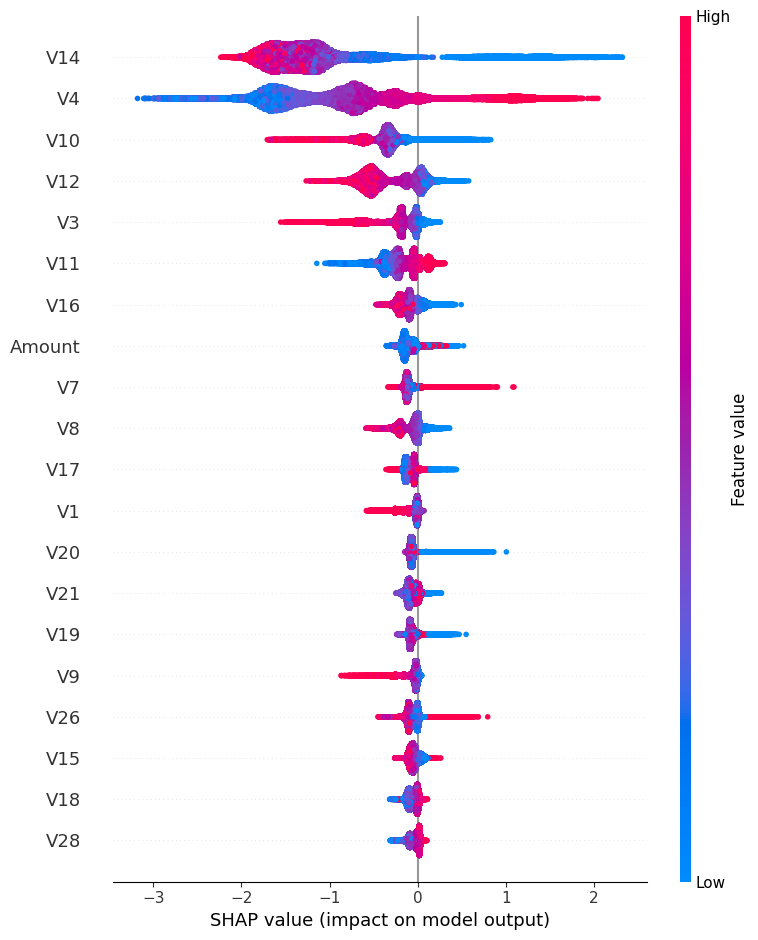

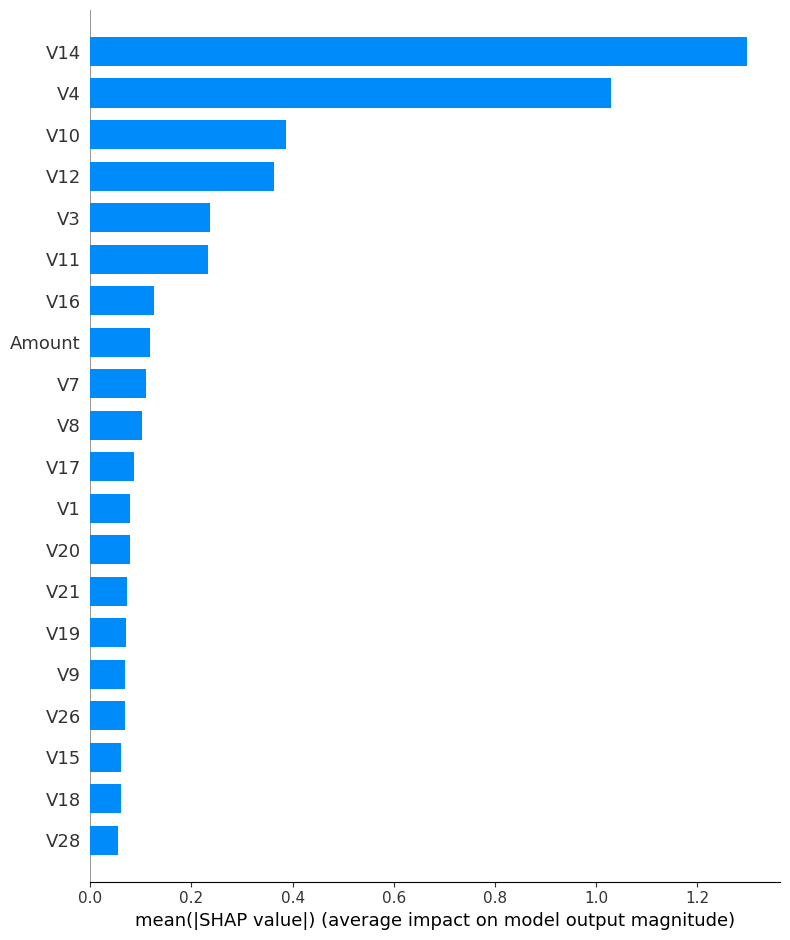

In [ ]:
interpretar_shap_xgb(best_model_bal, X)

##Modelagem com oversampling

In [74]:
X_smote_ref = ray.put(X_smote)
y_smote_ref = ray.put(y_smote)

In [ ]:
# Treinamento do Modelo
results_xbg_smote = busca(tune.with_parameters(train_xgb, oversampling=True, scale_pos_weight=None), search_space=search_space, scheduler=scheduler)

# Melhor modelo
best_result_smote = results_xbg_smote.get_best_result(metric="logloss", mode="min")

best_model_smote = TuneReportCheckpointCallback.get_model(best_result_smote.checkpoint)

print("Melhores parâmetros encontrados:")
print(best_result_smote.config)

#Avaliação final
avalicao_final(best_model_smote, X_test_xgb, y_test_xgb)


+------------------------------------------------------------------+
| Configuration for experiment     train_xgb_2026-02-21_01-00-56   |
+------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator           |
| Scheduler                        AsyncHyperBandScheduler         |
| Number of trials                 30                              |
+------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_xgb_2026-02-21_01-00-56
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-02-20_22-28-45_813687_543/artifacts/2026-02-21_01-00-56/train_xgb_2026-02-21_01-00-56/driver_artifacts`

Trial status: 30 PENDING
Current time: 2026-02-21 01:00:57. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------------------------------------------

(train_xgb pid=130022) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00000_0_colsample_bytree=0.7201,eta=0.0012,gamma=2.5386,max_depth=4,min_child_weight=6,reg_alpha=2.7794,reg_lambda_2026-02-21_01-00-57/checkpoint_000000)
(train_xgb pid=130022) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00000_0_colsample_bytree=0.7201,eta=0.0012,gamma=2.5386,max_depth=4,min_child_weight=6,reg_alpha=2.7794,reg_lambda_2026-02-21_01-00-57/checkpoint_000037) [repeated 77x across cluster]



Trial train_xgb_c790c_00000 completed after 63 iterations at 2026-02-21 01:01:35. Total running time: 38s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00000 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000062 |
| time_this_iter_s                                 0.08281 |
| time_total_s                                    11.36928 |
| training_iteration                                    63 |
| auc                                              0.97627 |
| logloss                                          0.63441 |
+----------------------------------------------------------+


(train_xgb pid=130068) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00001_1_colsample_bytree=0.7916,eta=0.0038,gamma=1.8435,max_depth=3,min_child_weight=10,reg_alpha=2.5438,reg_lambd_2026-02-21_01-00-57/checkpoint_000091) [repeated 77x across cluster]
(train_xgb pid=130068) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00001_1_colsample_bytree=0.7916,eta=0.0038,gamma=1.8435,max_depth=3,min_child_weight=10,reg_alpha=2.5438,reg_lambd_2026-02-21_01-00-57/checkpoint_000139) [repeated 48x across cluster]
(train_xgb pid=130068) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00001_1_colsample_bytree=0.7916,eta=0.0038,gamma=1.8435,max_depth=3,min_child_weight=10,reg_alpha=2.5438,reg_lambd_2026-02-21_01-00-57/checkpoint_000164) [repeat


Trial train_xgb_c790c_00002 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00002 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.71328 |
| eta                                               0.00166 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                               1.619 |
| max_depth                                               3 |
| min_child_weight                                        5 |
| objective                                 binary:logistic |
| reg_alpha                                         3.32131 |
| reg_lambda                                       14.81681 |
| subsample                                         0.67269 |
| tree_method                                          hist |
+-----------------------------------------------------------+

Trial train_

(train_xgb pid=130310) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00002_2_colsample_bytree=0.7133,eta=0.0017,gamma=1.6190,max_depth=3,min_child_weight=5,reg_alpha=3.3213,reg_lambda_2026-02-21_01-00-57/checkpoint_000000) [repeated 18x across cluster]
(train_xgb pid=130310) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00002_2_colsample_bytree=0.7133,eta=0.0017,gamma=1.6190,max_depth=3,min_child_weight=5,reg_alpha=3.3213,reg_lambda_2026-02-21_01-00-57/checkpoint_000054) [repeated 54x across cluster]



Trial train_xgb_c790c_00002 completed after 100 iterations at 2026-02-21 01:02:11. Total running time: 1min 14s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00002 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.06783 |
| time_total_s                                    15.47946 |
| training_iteration                                   100 |
| auc                                              0.97496 |
| logloss                                          0.57208 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00003 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00003 config                        |
+-----------------------------------------------------------+
| colsample_bytree                

(train_xgb pid=130461) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00003_3_colsample_bytree=0.6710,eta=0.0094,gamma=2.4795,max_depth=3,min_child_weight=7,reg_alpha=3.4575,reg_lambda_2026-02-21_01-00-57/checkpoint_000000) [repeated 46x across cluster]
(train_xgb pid=130461) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00003_3_colsample_bytree=0.6710,eta=0.0094,gamma=2.4795,max_depth=3,min_child_weight=7,reg_alpha=3.4575,reg_lambda_2026-02-21_01-00-57/checkpoint_000057) [repeated 57x across cluster]



Trial status: 3 TERMINATED | 1 RUNNING | 26 PENDING
Current time: 2026-02-21 01:02:28. Total running time: 1min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00001 with logloss=0.2871676786628161 and params={'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.7202062269989986, 'colsample_bytree': 0.7916479531106788, 'eta': 0.003774884888546937, 'gamma': 1.8435469346776114, 'reg_alpha': 2.5438351353038025, 'reg_lambda': 12.726930458188523, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     loglo

(train_xgb pid=130461) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00003_3_colsample_bytree=0.6710,eta=0.0094,gamma=2.4795,max_depth=3,min_child_weight=7,reg_alpha=3.4575,reg_lambda_2026-02-21_01-00-57/checkpoint_000098) [repeated 41x across cluster]



Trial train_xgb_c790c_00003 completed after 111 iterations at 2026-02-21 01:02:33. Total running time: 1min 36s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00003 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000110 |
| time_this_iter_s                                 0.06887 |
| time_total_s                                    14.24733 |
| training_iteration                                   111 |
| auc                                              0.97456 |
| logloss                                           0.2564 |
+----------------------------------------------------------+


(train_xgb pid=130592) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00004_4_colsample_bytree=0.7495,eta=0.0031,gamma=1.2762,max_depth=4,min_child_weight=6,reg_alpha=3.5950,reg_lambda_2026-02-21_01-00-57/checkpoint_000006) [repeated 19x across cluster]
(train_xgb pid=130592) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00004_4_colsample_bytree=0.7495,eta=0.0031,gamma=1.2762,max_depth=4,min_child_weight=6,reg_alpha=3.5950,reg_lambda_2026-02-21_01-00-57/checkpoint_000045) [repeated 39x across cluster]



Trial train_xgb_c790c_00004 completed after 64 iterations at 2026-02-21 01:02:47. Total running time: 1min 50s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00004 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000063 |
| time_this_iter_s                                 0.06898 |
| time_total_s                                    14.12499 |
| training_iteration                                    64 |
| auc                                              0.97104 |
| logloss                                           0.5479 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00005 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00005 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=130753) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00005_5_colsample_bytree=0.6206,eta=0.0044,gamma=2.0929,max_depth=3,min_child_weight=10,reg_alpha=2.9604,reg_lambd_2026-02-21_01-00-57/checkpoint_000001) [repeated 20x across cluster]



Trial train_xgb_c790c_00006 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00006 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.75084 |
| eta                                               0.03373 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             3.20072 |
| max_depth                                               3 |
| min_child_weight                                       10 |
| objective                                 binary:logistic |
| reg_alpha                                         4.57165 |
| reg_lambda                                       16.72185 |
| subsample                                         0.72814 |
| tree_method                                          hist |
+-----------------------------------------------------------+

Trial train_

(train_xgb pid=130871) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00006_6_colsample_bytree=0.7508,eta=0.0337,gamma=3.2007,max_depth=3,min_child_weight=10,reg_alpha=4.5716,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 56x across cluster]
(train_xgb pid=130871) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00006_6_colsample_bytree=0.7508,eta=0.0337,gamma=3.2007,max_depth=3,min_child_weight=10,reg_alpha=4.5716,reg_lambd_2026-02-21_01-00-57/checkpoint_000023) [repeated 23x across cluster]
(train_xgb pid=130871) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00006_6_colsample_bytree=0.7508,eta=0.0337,gamma=3.2007,max_depth=3,min_child_weight=10,reg_alpha=4.5716,reg_lambd_2026-02-21_01-00-57/checkpoint_000071) [repeat


Trial train_xgb_c790c_00007 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00007 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.65252 |
| eta                                               0.00146 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             3.60911 |
| max_depth                                               4 |
| min_child_weight                                        8 |
| objective                                 binary:logistic |
| reg_alpha                                         2.35929 |
| reg_lambda                                        6.78724 |
| subsample                                         0.78021 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=130871) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00006_6_colsample_bytree=0.7508,eta=0.0337,gamma=3.2007,max_depth=3,min_child_weight=10,reg_alpha=4.5716,reg_lambd_2026-02-21_01-00-57/checkpoint_000131) [repeated 60x across cluster]



Trial status: 6 TERMINATED | 2 RUNNING | 22 PENDING
Current time: 2026-02-21 01:03:28. Total running time: 2min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00006 with logloss=0.0603726033044158 and params={'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.7281356284546812, 'colsample_bytree': 0.7508373602897157, 'eta': 0.033730303409906785, 'gamma': 3.2007230023592133, 'reg_alpha': 4.571648080511167, 'reg_lambda': 16.72184990318164, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     logloss

(train_xgb pid=130871) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00006_6_colsample_bytree=0.7508,eta=0.0337,gamma=3.2007,max_depth=3,min_child_weight=10,reg_alpha=4.5716,reg_lambd_2026-02-21_01-00-57/checkpoint_000166) [repeated 35x across cluster]



Trial train_xgb_c790c_00006 completed after 206 iterations at 2026-02-21 01:03:33. Total running time: 2min 36s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00006 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000205 |
| time_this_iter_s                                 0.08609 |
| time_total_s                                    25.74425 |
| training_iteration                                   206 |
| auc                                              0.97984 |
| logloss                                          0.05003 |
+----------------------------------------------------------+


(train_xgb pid=131025) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00007_7_colsample_bytree=0.6525,eta=0.0015,gamma=3.6091,max_depth=4,min_child_weight=8,reg_alpha=2.3593,reg_lambda_2026-02-21_01-00-57/checkpoint_000049) [repeated 89x across cluster]
(train_xgb pid=131025) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00007_7_colsample_bytree=0.6525,eta=0.0015,gamma=3.6091,max_depth=4,min_child_weight=8,reg_alpha=2.3593,reg_lambda_2026-02-21_01-00-57/checkpoint_000089) [repeated 40x across cluster]



Trial train_xgb_c790c_00007 completed after 100 iterations at 2026-02-21 01:03:44. Total running time: 2min 47s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00007 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                  0.0736 |
| time_total_s                                    19.17342 |
| training_iteration                                   100 |
| auc                                              0.97874 |
| logloss                                          0.58279 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00008 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00008 config                        |
+-----------------------------------------------------------+
| colsample_bytree                

(train_xgb pid=131206) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00008_8_colsample_bytree=0.6373,eta=0.0091,gamma=1.4255,max_depth=4,min_child_weight=10,reg_alpha=3.0485,reg_lambd_2026-02-21_01-00-57/checkpoint_000001) [repeated 12x across cluster]



Trial train_xgb_c790c_00009 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00009 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.61795 |
| eta                                               0.00598 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             2.48664 |
| max_depth                                               3 |
| min_child_weight                                        8 |
| objective                                 binary:logistic |
| reg_alpha                                         3.97643 |
| reg_lambda                                       12.86127 |
| subsample                                         0.69919 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=131206) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00008_8_colsample_bytree=0.6373,eta=0.0091,gamma=1.4255,max_depth=4,min_child_weight=10,reg_alpha=3.0485,reg_lambd_2026-02-21_01-00-57/checkpoint_000058) [repeated 57x across cluster]
(train_xgb pid=131206) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00008_8_colsample_bytree=0.6373,eta=0.0091,gamma=1.4255,max_depth=4,min_child_weight=10,reg_alpha=3.0485,reg_lambd_2026-02-21_01-00-57/checkpoint_000111) [repeated 82x across cluster]



Trial train_xgb_c790c_00009 completed after 57 iterations at 2026-02-21 01:04:13. Total running time: 3min 16s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00009 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000056 |
| time_this_iter_s                                 0.07148 |
| time_total_s                                      9.7062 |
| training_iteration                                    57 |
| auc                                              0.97693 |
| logloss                                          0.47776 |
+----------------------------------------------------------+


(train_xgb pid=131206) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00008_8_colsample_bytree=0.6373,eta=0.0091,gamma=1.4255,max_depth=4,min_child_weight=10,reg_alpha=3.0485,reg_lambd_2026-02-21_01-00-57/checkpoint_000146) [repeated 63x across cluster]
(train_xgb pid=131206) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00008_8_colsample_bytree=0.6373,eta=0.0091,gamma=1.4255,max_depth=4,min_child_weight=10,reg_alpha=3.0485,reg_lambd_2026-02-21_01-00-57/checkpoint_000187) [repeated 41x across cluster]
(train_xgb pid=131206) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00008_8_colsample_bytree=0.6373,eta=0.0091,gamma=1.4255,max_depth=4,min_child_weight=10,reg_alpha=3.0485,reg_lambd_2026-02-21_01-00-57/checkpoint_000218) [repeat


Trial train_xgb_c790c_00008 completed after 231 iterations at 2026-02-21 01:04:27. Total running time: 3min 30s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00008 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000230 |
| time_this_iter_s                                 0.09661 |
| time_total_s                                    31.95814 |
| training_iteration                                   231 |
| auc                                               0.9787 |
| logloss                                          0.11972 |
+----------------------------------------------------------+

Trial status: 10 TERMINATED | 20 PENDING
Current time: 2026-02-21 01:04:28. Total running time: 3min 31s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00006 with logloss=0.05003428683246713 and params={'max_depth': 3, 'min_child_weight': 10, 'subsampl

(train_xgb pid=131511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00010_10_colsample_bytree=0.7401,eta=0.0059,gamma=3.0509,max_depth=4,min_child_weight=10,reg_alpha=3.0146,reg_lamb_2026-02-21_01-00-57/checkpoint_000000) [repeated 13x across cluster]
(train_xgb pid=131511) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00010_10_colsample_bytree=0.7401,eta=0.0059,gamma=3.0509,max_depth=4,min_child_weight=10,reg_alpha=3.0146,reg_lamb_2026-02-21_01-00-57/checkpoint_000043) [repeated 43x across cluster]



Trial train_xgb_c790c_00010 completed after 63 iterations at 2026-02-21 01:04:46. Total running time: 3min 49s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00010 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000062 |
| time_this_iter_s                                 0.07911 |
| time_total_s                                    11.85307 |
| training_iteration                                    63 |
| auc                                              0.97583 |
| logloss                                          0.45341 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00011 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00011 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=131634) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00011_11_colsample_bytree=0.7366,eta=0.0012,gamma=2.3888,max_depth=4,min_child_weight=7,reg_alpha=3.1581,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 20x across cluster]
(train_xgb pid=131634) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00011_11_colsample_bytree=0.7366,eta=0.0012,gamma=2.3888,max_depth=4,min_child_weight=7,reg_alpha=3.1581,reg_lambd_2026-02-21_01-00-57/checkpoint_000012) [repeated 12x across cluster]



Trial status: 11 TERMINATED | 1 RUNNING | 18 PENDING
Current time: 2026-02-21 01:04:58. Total running time: 4min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00006 with logloss=0.05003428683246713 and params={'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.7281356284546812, 'colsample_bytree': 0.7508373602897157, 'eta': 0.033730303409906785, 'gamma': 3.2007230023592133, 'reg_alpha': 4.571648080511167, 'reg_lambda': 16.72184990318164, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     loglos

(train_xgb pid=131634) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00011_11_colsample_bytree=0.7366,eta=0.0012,gamma=2.3888,max_depth=4,min_child_weight=7,reg_alpha=3.1581,reg_lambd_2026-02-21_01-00-57/checkpoint_000064) [repeated 52x across cluster]



Trial train_xgb_c790c_00011 completed after 71 iterations at 2026-02-21 01:05:02. Total running time: 4min 5s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00011 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000070 |
| time_this_iter_s                                 0.07061 |
| time_total_s                                    14.91982 |
| training_iteration                                    71 |
| auc                                              0.97186 |
| logloss                                          0.62334 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00012 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00012 config                        |
+-----------------------------------------------------------+
| colsample_bytree                  

(train_xgb pid=131780) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00012_12_colsample_bytree=0.7351,eta=0.0011,gamma=1.1424,max_depth=4,min_child_weight=10,reg_alpha=1.4090,reg_lamb_2026-02-21_01-00-57/checkpoint_000000) [repeated 7x across cluster]
(train_xgb pid=131780) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00012_12_colsample_bytree=0.7351,eta=0.0011,gamma=1.1424,max_depth=4,min_child_weight=10,reg_alpha=1.4090,reg_lamb_2026-02-21_01-00-57/checkpoint_000060) [repeated 60x across cluster]



Trial train_xgb_c790c_00012 completed after 71 iterations at 2026-02-21 01:05:19. Total running time: 4min 22s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00012 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000070 |
| time_this_iter_s                                 0.07533 |
| time_total_s                                    13.07116 |
| training_iteration                                    71 |
| auc                                              0.97211 |
| logloss                                          0.63264 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00013 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00013 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=131916) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00013_13_colsample_bytree=0.6407,eta=0.0039,gamma=2.8104,max_depth=3,min_child_weight=6,reg_alpha=2.2867,reg_lambd_2026-02-21_01-00-57/checkpoint_000001) [repeated 12x across cluster]
(train_xgb pid=131916) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00013_13_colsample_bytree=0.6407,eta=0.0039,gamma=2.8104,max_depth=3,min_child_weight=6,reg_alpha=2.2867,reg_lambd_2026-02-21_01-00-57/checkpoint_000062) [repeated 61x across cluster]



Trial train_xgb_c790c_00013 completed after 100 iterations at 2026-02-21 01:05:37. Total running time: 4min 40s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00013 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                 0.13187 |
| time_total_s                                     15.9637 |
| training_iteration                                   100 |
| auc                                              0.97661 |
| logloss                                          0.45414 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00014 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00014 config                        |
+-----------------------------------------------------------+
| colsample_bytree                

(train_xgb pid=132065) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00014_14_colsample_bytree=0.7556,eta=0.0499,gamma=3.6722,max_depth=3,min_child_weight=7,reg_alpha=2.3055,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 38x across cluster]
(train_xgb pid=132065) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00014_14_colsample_bytree=0.7556,eta=0.0499,gamma=3.6722,max_depth=3,min_child_weight=7,reg_alpha=2.3055,reg_lambd_2026-02-21_01-00-57/checkpoint_000043) [repeated 43x across cluster]
(train_xgb pid=132065) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00014_14_colsample_bytree=0.7556,eta=0.0499,gamma=3.6722,max_depth=3,min_child_weight=7,reg_alpha=2.3055,reg_lambd_2026-02-21_01-00-57/checkpoint_000071) [repeat


Trial status: 14 TERMINATED | 1 RUNNING | 15 PENDING
Current time: 2026-02-21 01:05:58. Total running time: 5min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00006 with logloss=0.05003428683246713 and params={'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.7281356284546812, 'colsample_bytree': 0.7508373602897157, 'eta': 0.033730303409906785, 'gamma': 3.2007230023592133, 'reg_alpha': 4.571648080511167, 'reg_lambda': 16.72184990318164, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     loglos

(train_xgb pid=132065) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00014_14_colsample_bytree=0.7556,eta=0.0499,gamma=3.6722,max_depth=3,min_child_weight=7,reg_alpha=2.3055,reg_lambd_2026-02-21_01-00-57/checkpoint_000129) [repeated 58x across cluster]



Trial train_xgb_c790c_00014 completed after 181 iterations at 2026-02-21 01:06:06. Total running time: 5min 9s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00014 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000180 |
| time_this_iter_s                                 0.08167 |
| time_total_s                                    21.68014 |
| training_iteration                                   181 |
| auc                                              0.98014 |
| logloss                                          0.04002 |
+----------------------------------------------------------+


(train_xgb pid=132201) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00015_15_colsample_bytree=0.7644,eta=0.0108,gamma=3.2980,max_depth=4,min_child_weight=9,reg_alpha=4.8280,reg_lambd_2026-02-21_01-00-57/checkpoint_000041) [repeated 93x across cluster]
(train_xgb pid=132201) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00015_15_colsample_bytree=0.7644,eta=0.0108,gamma=3.2980,max_depth=4,min_child_weight=9,reg_alpha=4.8280,reg_lambd_2026-02-21_01-00-57/checkpoint_000058) [repeated 17x across cluster]



Trial train_xgb_c790c_00015 completed after 71 iterations at 2026-02-21 01:06:13. Total running time: 5min 16s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00015 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000070 |
| time_this_iter_s                                  0.0698 |
| time_total_s                                    12.85861 |
| training_iteration                                    71 |
| auc                                              0.97773 |
| logloss                                          0.30982 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00016 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00016 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000001) [repeated 14x across cluster]
(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000061) [repeated 103x across cluster]
(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000100) [repea


Trial status: 16 TERMINATED | 2 RUNNING | 12 PENDING
Current time: 2026-02-21 01:06:58. Total running time: 6min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00014 with logloss=0.04002162228857332 and params={'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.6385133052642957, 'colsample_bytree': 0.7556210135473435, 'eta': 0.049942739945069176, 'gamma': 3.672235038300407, 'reg_alpha': 2.3054585631489575, 'reg_lambda': 6.4302181858577505, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     loglos

(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000294) [repeated 99x across cluster]
(train_xgb pid=132402) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00017_17_colsample_bytree=0.7213,eta=0.0171,gamma=2.4775,max_depth=4,min_child_weight=8,reg_alpha=3.9558,reg_lambd_2026-02-21_01-00-57/checkpoint_000298) [repeated 83x across cluster]
(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000375) [repeat


Trial train_xgb_c790c_00017 completed after 363 iterations at 2026-02-21 01:07:15. Total running time: 6min 18s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00017 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000362 |
| time_this_iter_s                                 0.09471 |
| time_total_s                                    41.96287 |
| training_iteration                                   363 |
| auc                                              0.98294 |
| logloss                                          0.03875 |
+----------------------------------------------------------+


(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000418) [repeated 71x across cluster]
(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000439) [repeated 21x across cluster]
(train_xgb pid=132396) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00016_16_colsample_bytree=0.7112,eta=0.0123,gamma=3.4538,max_depth=3,min_child_weight=10,reg_alpha=1.4906,reg_lamb_2026-02-21_01-00-57/checkpoint_000478) [repeat


Trial status: 17 TERMINATED | 1 RUNNING | 12 PENDING
Current time: 2026-02-21 01:07:28. Total running time: 6min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00017 with logloss=0.03875201771236632 and params={'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.6764794958549585, 'colsample_bytree': 0.7213171801537611, 'eta': 0.01709295136273172, 'gamma': 2.4775049246145455, 'reg_alpha': 3.955784341816503, 'reg_lambda': 13.409100086204027, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     loglos

(train_xgb pid=132780) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00018_18_colsample_bytree=0.6111,eta=0.0123,gamma=2.6064,max_depth=3,min_child_weight=8,reg_alpha=2.8183,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 40x across cluster]



Trial train_xgb_c790c_00018 completed after 57 iterations at 2026-02-21 01:07:45. Total running time: 6min 48s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00018 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000056 |
| time_this_iter_s                                 0.06181 |
| time_total_s                                     11.0192 |
| training_iteration                                    57 |
| auc                                              0.97758 |
| logloss                                          0.34107 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00019 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00019 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=132918) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00019_19_colsample_bytree=0.6997,eta=0.0021,gamma=1.2546,max_depth=4,min_child_weight=8,reg_alpha=2.8810,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 57x across cluster]



Trial status: 19 TERMINATED | 1 RUNNING | 10 PENDING
Current time: 2026-02-21 01:07:58. Total running time: 7min 1s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00017 with logloss=0.03875201771236632 and params={'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.6764794958549585, 'colsample_bytree': 0.7213171801537611, 'eta': 0.01709295136273172, 'gamma': 2.4775049246145455, 'reg_alpha': 3.955784341816503, 'reg_lambda': 13.409100086204027, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     logloss

(train_xgb pid=132918) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00019_19_colsample_bytree=0.6997,eta=0.0021,gamma=1.2546,max_depth=4,min_child_weight=8,reg_alpha=2.8810,reg_lambd_2026-02-21_01-00-57/checkpoint_000059) [repeated 59x across cluster]



Trial train_xgb_c790c_00020 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00020 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.69068 |
| eta                                               0.01301 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             2.42044 |
| max_depth                                               4 |
| min_child_weight                                        9 |
| objective                                 binary:logistic |
| reg_alpha                                         2.75091 |
| reg_lambda                                        11.2742 |
| subsample                                          0.6019 |
| tree_method                                          hist |
+-----------------------------------------------------------+

Trial train_

(train_xgb pid=133042) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00020_20_colsample_bytree=0.6907,eta=0.0130,gamma=2.4204,max_depth=4,min_child_weight=9,reg_alpha=2.7509,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 32x across cluster]
(train_xgb pid=133042) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00020_20_colsample_bytree=0.6907,eta=0.0130,gamma=2.4204,max_depth=4,min_child_weight=9,reg_alpha=2.7509,reg_lambd_2026-02-21_01-00-57/checkpoint_000051) [repeated 51x across cluster]



Trial train_xgb_c790c_00020 completed after 57 iterations at 2026-02-21 01:08:15. Total running time: 7min 18s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00020 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000056 |
| time_this_iter_s                                 0.07633 |
| time_total_s                                     10.8485 |
| training_iteration                                    57 |
| auc                                               0.9753 |
| logloss                                          0.31865 |
+----------------------------------------------------------+

Trial status: 21 TERMINATED | 9 PENDING
Current time: 2026-02-21 01:08:28. Total running time: 7min 31s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00017 with logloss=0.03875201771236632 and params={'max_depth': 4, 'min_child_weight': 8, 'subsample':

(train_xgb pid=133204) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00021_21_colsample_bytree=0.7481,eta=0.0103,gamma=3.9292,max_depth=4,min_child_weight=5,reg_alpha=3.8834,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 6x across cluster]
(train_xgb pid=133204) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00021_21_colsample_bytree=0.7481,eta=0.0103,gamma=3.9292,max_depth=4,min_child_weight=5,reg_alpha=3.8834,reg_lambd_2026-02-21_01-00-57/checkpoint_000055) [repeated 67x across cluster]



Trial train_xgb_c790c_00021 completed after 71 iterations at 2026-02-21 01:08:56. Total running time: 7min 59s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00021 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000070 |
| time_this_iter_s                                 0.16006 |
| time_total_s                                    10.95859 |
| training_iteration                                    71 |
| auc                                              0.97779 |
| logloss                                          0.32087 |
+----------------------------------------------------------+

Trial status: 22 TERMINATED | 1 RUNNING | 7 PENDING
Current time: 2026-02-21 01:08:58. Total running time: 8min 1s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00017 with logloss=0.03875201771236632 and params={'max_depth': 4, 'min_child_weight': 8, '

(train_xgb pid=133315) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00022_22_colsample_bytree=0.6623,eta=0.0109,gamma=3.1402,max_depth=3,min_child_weight=8,reg_alpha=3.2578,reg_lambd_2026-02-21_01-00-57/checkpoint_000041) [repeated 45x across cluster]
(train_xgb pid=133315) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00022_22_colsample_bytree=0.6623,eta=0.0109,gamma=3.1402,max_depth=3,min_child_weight=8,reg_alpha=3.2578,reg_lambd_2026-02-21_01-00-57/checkpoint_000086) [repeated 45x across cluster]



Trial train_xgb_c790c_00022 completed after 120 iterations at 2026-02-21 01:09:06. Total running time: 8min 9s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00022 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000119 |
| time_this_iter_s                                 0.06901 |
| time_total_s                                    16.47593 |
| training_iteration                                   120 |
| auc                                              0.97511 |
| logloss                                          0.21246 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00023 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00023 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=133539) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00023_23_colsample_bytree=0.6802,eta=0.0129,gamma=1.2775,max_depth=3,min_child_weight=9,reg_alpha=2.1459,reg_lambd_2026-02-21_01-00-57/checkpoint_000001) [repeated 35x across cluster]
(train_xgb pid=133539) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00023_23_colsample_bytree=0.6802,eta=0.0129,gamma=1.2775,max_depth=3,min_child_weight=9,reg_alpha=2.1459,reg_lambd_2026-02-21_01-00-57/checkpoint_000048) [repeated 47x across cluster]



Trial train_xgb_c790c_00024 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00024 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.68895 |
| eta                                               0.00938 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             2.84685 |
| max_depth                                               4 |
| min_child_weight                                        6 |
| objective                                 binary:logistic |
| reg_alpha                                         3.67016 |
| reg_lambda                                       15.25266 |
| subsample                                         0.67259 |
| tree_method                                          hist |
+-----------------------------------------------------------+

Trial status

(train_xgb pid=133539) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00023_23_colsample_bytree=0.6802,eta=0.0129,gamma=1.2775,max_depth=3,min_child_weight=9,reg_alpha=2.1459,reg_lambd_2026-02-21_01-00-57/checkpoint_000107) [repeated 64x across cluster]



Trial train_xgb_c790c_00023 completed after 147 iterations at 2026-02-21 01:09:34. Total running time: 8min 37s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00023 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000146 |
| time_this_iter_s                                 0.08003 |
| time_total_s                                    15.62322 |
| training_iteration                                   147 |
| auc                                              0.97595 |
| logloss                                          0.14769 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00024 completed after 57 iterations at 2026-02-21 01:09:35. Total running time: 8min 38s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00024 result                       |
+------------------------------------------

(train_xgb pid=133844) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00025_25_colsample_bytree=0.7319,eta=0.0037,gamma=3.0966,max_depth=4,min_child_weight=5,reg_alpha=2.3788,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 92x across cluster]
(train_xgb pid=133844) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00025_25_colsample_bytree=0.7319,eta=0.0037,gamma=3.0966,max_depth=4,min_child_weight=5,reg_alpha=2.3788,reg_lambd_2026-02-21_01-00-57/checkpoint_000057) [repeated 102x across cluster]



Trial train_xgb_c790c_00025 completed after 63 iterations at 2026-02-21 01:10:05. Total running time: 9min 8s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00025 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000062 |
| time_this_iter_s                                 0.07477 |
| time_total_s                                     8.43275 |
| training_iteration                                    63 |
| auc                                              0.97581 |
| logloss                                          0.52819 |
+----------------------------------------------------------+


(train_xgb pid=133874) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00026_26_colsample_bytree=0.7475,eta=0.0014,gamma=3.2717,max_depth=3,min_child_weight=7,reg_alpha=2.6604,reg_lambd_2026-02-21_01-00-57/checkpoint_000065) [repeated 26x across cluster]



Trial train_xgb_c790c_00026 completed after 100 iterations at 2026-02-21 01:10:13. Total running time: 9min 16s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00026 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000099 |
| time_this_iter_s                                  0.0647 |
| time_total_s                                    14.58624 |
| training_iteration                                   100 |
| auc                                              0.97524 |
| logloss                                          0.58845 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00027 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00027 config                        |
+-----------------------------------------------------------+
| colsample_bytree                

(train_xgb pid=134100) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00027_27_colsample_bytree=0.6297,eta=0.0285,gamma=3.4130,max_depth=4,min_child_weight=6,reg_alpha=1.7593,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 35x across cluster]



Trial train_xgb_c790c_00028 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00028 config                        |
+-----------------------------------------------------------+
| colsample_bytree                                  0.74813 |
| eta                                               0.00228 |
| eval_metric                            ['logloss', 'auc'] |
| gamma                                             2.74879 |
| max_depth                                               4 |
| min_child_weight                                        5 |
| objective                                 binary:logistic |
| reg_alpha                                         3.66535 |
| reg_lambda                                        10.2551 |
| subsample                                         0.71117 |
| tree_method                                          hist |
+-----------------------------------------------------------+


(train_xgb pid=134100) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00027_27_colsample_bytree=0.6297,eta=0.0285,gamma=3.4130,max_depth=4,min_child_weight=6,reg_alpha=1.7593,reg_lambd_2026-02-21_01-00-57/checkpoint_000051) [repeated 52x across cluster]



Trial train_xgb_c790c_00027 completed after 92 iterations at 2026-02-21 01:10:41. Total running time: 9min 44s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00027 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000091 |
| time_this_iter_s                                 0.09006 |
| time_total_s                                    12.31872 |
| training_iteration                                    92 |
| auc                                              0.97557 |
| logloss                                          0.09133 |
+----------------------------------------------------------+


(train_xgb pid=134195) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00028_28_colsample_bytree=0.7481,eta=0.0023,gamma=2.7488,max_depth=4,min_child_weight=5,reg_alpha=3.6654,reg_lambd_2026-02-21_01-00-57/checkpoint_000046) [repeated 86x across cluster]



Trial train_xgb_c790c_00028 completed after 71 iterations at 2026-02-21 01:10:45. Total running time: 9min 48s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00028 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000070 |
| time_this_iter_s                                 0.09074 |
| time_total_s                                    12.31086 |
| training_iteration                                    71 |
| auc                                              0.97425 |
| logloss                                          0.57094 |
+----------------------------------------------------------+

Trial train_xgb_c790c_00029 started with configuration:
+-----------------------------------------------------------+
| Trial train_xgb_c790c_00029 config                        |
+-----------------------------------------------------------+
| colsample_bytree                 

(train_xgb pid=134380) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/root/ray_results/train_xgb_2026-02-21_01-00-56/train_xgb_c790c_00029_29_colsample_bytree=0.6610,eta=0.0025,gamma=1.9379,max_depth=3,min_child_weight=6,reg_alpha=1.8058,reg_lambd_2026-02-21_01-00-57/checkpoint_000000) [repeated 25x across cluster]



Trial status: 29 TERMINATED | 1 RUNNING
Current time: 2026-02-21 01:10:58. Total running time: 10min 1s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00017 with logloss=0.03875201771236632 and params={'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.6764794958549585, 'colsample_bytree': 0.7213171801537611, 'eta': 0.01709295136273172, 'gamma': 2.4775049246145455, 'reg_alpha': 3.955784341816503, 'reg_lambda': 13.409100086204027, 'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'], 'tree_method': 'hist', 'scale_pos_weight': None}
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name              status         max_depth     min_child_weight     subsample     colsample_bytree          eta     gamma     reg_alpha     reg_lambda     iter     total time (s)     logloss        auc 

2026-02-21 01:11:00,645	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_xgb_2026-02-21_01-00-56' in 0.0716s.



Trial train_xgb_c790c_00029 completed after 56 iterations at 2026-02-21 01:11:00. Total running time: 10min 3s
+----------------------------------------------------------+
| Trial train_xgb_c790c_00029 result                       |
+----------------------------------------------------------+
| checkpoint_dir_name                    checkpoint_000055 |
| time_this_iter_s                                 0.04459 |
| time_total_s                                      4.9133 |
| training_iteration                                    56 |
| auc                                              0.97494 |
| logloss                                           0.5897 |
+----------------------------------------------------------+

Trial status: 30 TERMINATED
Current time: 2026-02-21 01:11:00. Total running time: 10min 3s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
Current best trial: c790c_00017 with logloss=0.03875201771236632 and params={'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.676479495

In [76]:
salvar(best_model_smote, best_result_smote.config, 'xgb_smote')

Modelo salvo com sucesso no arquivo xgb_smote.pkl


SHAP calculado com sucesso.


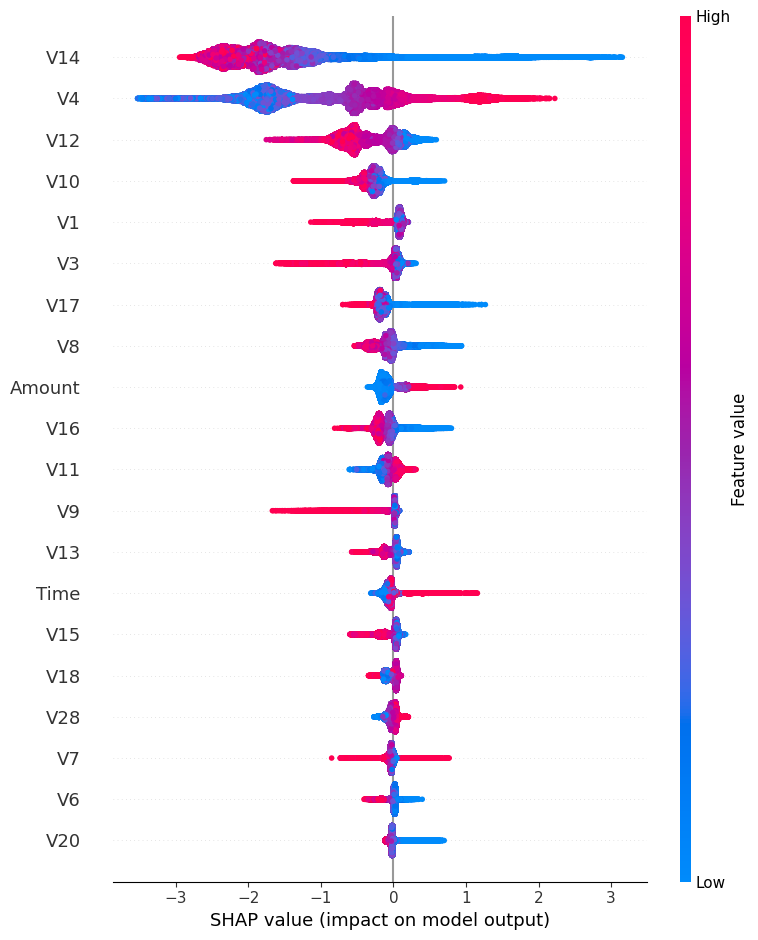

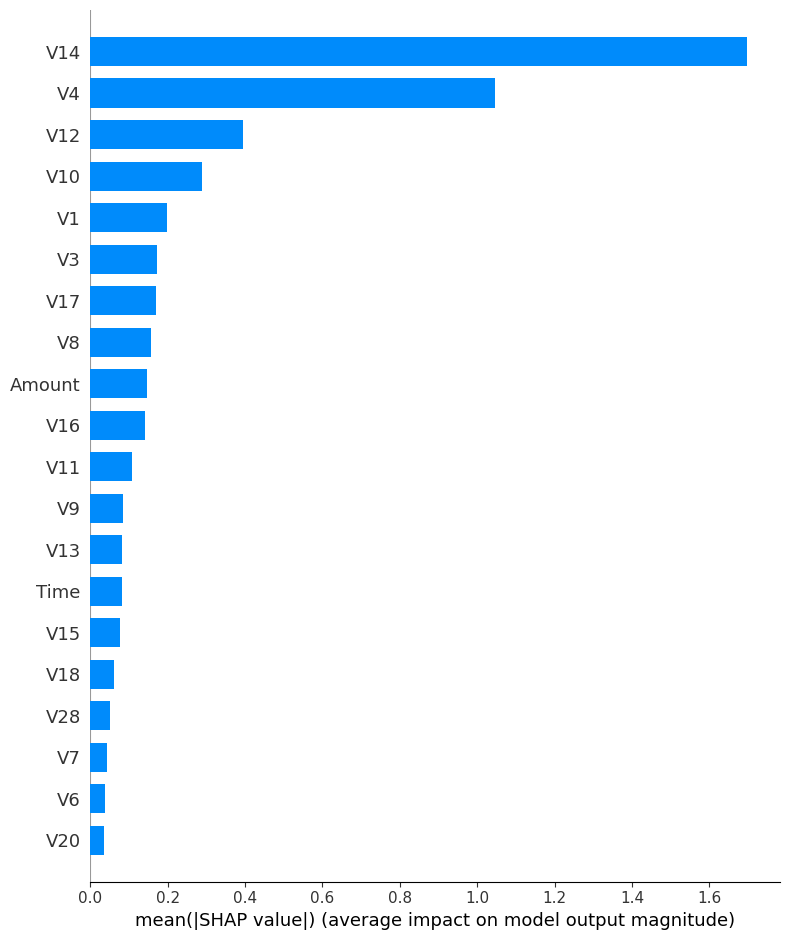

In [ ]:
interpretar_shap_xgb(best_model_smote, X)

##Conclusão

**Interpretação dos valores SHAP**

A análise das explicações geradas pelo SHAP para os modelos de XGBoost evidenciou um padrão consistente em relação à importância das variáveis ao longo das diferentes estratégias de modelagem.

A partir dos gráficos SHAP, foi possível constatar que:

* A variável V14 ocupou a primeira posição em importância em todas as estratégias de modelagem.
O padrão de contribuição da variável manteve-se estruturalmente semelhante entre os modelos.
Além disso, observou-se um comportamento específico:
Valores mais baixos de V14 estão associados a maior probabilidade de fraude.
Valores mais extremos positivos tendem a não contribuir significativamente para a classificação como fraude.

**Foco no melhor modelo (XGBoost com balanceamento interno)**

Ao analisar especificamente o modelo selecionado — aquele que utilizou técnica de balanceamento interno — observa-se que:

* A maior parte dos pontos com impacto positivo significativo na predição de fraude corresponde a valores extremos (outliers);

Tanto valores muito baixos quanto valores muito altos podem exercer forte influência na saída do modelo;

A concentração de impactos relevantes está associada a regiões de menor densidade da distribuição.

Esse comportamento está alinhado com a análise exploratória previamente realizada, na qual foi identificado que uma parcela significativa das transações fraudulentas está associada a valores extremos em determinadas variáveis.

Esse comportamento indica

Forte capacidade do modelo em capturar padrões não lineares;

Sensibilidade adequada a regiões de cauda da distribuição;

Coerência entre análise exploratória e comportamento do modelo;

**Resultados do Modelo Selecionado**

O melhor desempenho foi obtido pelo:

XGBoost com técnica de balanceamento interno ao modelo

Métricas de desempenho (Conjunto de Teste):

* **ROC AUC**: 0.988722

* **Log Loss**: 0.020716

Interpretação das Métricas

ROC AUC: Indica excelente capacidade discriminativa, evidenciando que o modelo consegue separar de forma muito eficaz as classes fraudulenta e não fraudulenta ao longo de diferentes limiares de decisão.

Log Loss: Valor bastante reduzido, indicando elevada qualidade probabilística. As probabilidades previstas estão muito próximas dos rótulos verdadeiros, sugerindo boa calibração e forte confiança do modelo nas previsões corretas.

#Regressão logística

In [ ]:
y_lr_train = y_train
y_lr_test = y_test

In [ ]:
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

##Funções Regressão Logística

In [ ]:
def lr_train(model, params, X_train, y_train):
  grid_search = GridSearchCV(
      model,
      params,
      cv=5,
      scoring='neg_log_loss',
      n_jobs=2
  )

  grid_search.fit(X_train, y_train)
  return grid_search

In [ ]:
def interpretar_shap_lr(
    model,
    X,
    instance_index=None,
    plot_summary=True,
    plot_bar=True,
    plot_local=False
):

  # Criando explainer linear
  explainer = shap.LinearExplainer(model, X)
  shap_values = explainer.shap_values(X)

  print("SHAP (Regressão Logística) calculado com sucesso.")

  # 📊 Summary plot
  if plot_summary:
      plt.figure()
      shap.summary_plot(shap_values, X)

  # 📊 Importância média
  if plot_bar:
      plt.figure()
      shap.summary_plot(shap_values, X, plot_type="bar")

  # 🔍 Explicação local
  if plot_local and instance_index is not None:
      shap.initjs()
      shap.force_plot(
          explainer.expected_value,
          shap_values[instance_index],
          X.iloc[instance_index]
      )

##Modelagem simples

In [ ]:
param_grid_lr_simples = [
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.1, 0.5, 1, 5],
    },
    {
        'solver': ['newton-cg'],
        'penalty': ['l2', None],
        'C': [0.1, 0.5, 1, 5],
    }
]


In [ ]:
grid_search_lr_simples = lr_train(LogisticRegression(), param_grid_lr_simples, X_train_scaled_lr, y_lr_train)

results_df_lr_simples= pd.DataFrame(grid_search_lr_simples.cv_results_)
results_df_lr_simples = results_df_lr_simples.sort_values(by=["rank_test_score"])
results_df_lr_simples = results_df_lr_simples.set_index(
    results_df_lr_simples["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df_lr_simples[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
0.5_l1_liblinear,"{'C': 0.5, 'penalty': 'l1', 'solver': 'libline...",1,-0.004321,0.000312
1_l2_liblinear,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",2,-0.004327,0.000300
0.1_l2_newton-cg,"{'C': 0.1, 'penalty': 'l2', 'solver': 'newton-...",3,-0.004329,0.000302
0.5_l2_liblinear,"{'C': 0.5, 'penalty': 'l2', 'solver': 'libline...",4,-0.004331,0.000294
0.5_l2_newton-cg,"{'C': 0.5, 'penalty': 'l2', 'solver': 'newton-...",5,-0.004331,0.000301
1_l2_newton-cg,"{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}",6,-0.004333,0.000301
1_l1_liblinear,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",7,-0.004333,0.000312
5_l2_newton-cg,"{'C': 5, 'penalty': 'l2', 'solver': 'newton-cg'}",8,-0.004334,0.000301
0.5_None_newton-cg,"{'C': 0.5, 'penalty': None, 'solver': 'newton-...",9,-0.004335,0.000301


In [ ]:
y_pred_lr_simples = grid_search_lr_simples.best_estimator_.predict_proba(X_test_scaled_lr)
print(f'Roc score: {roc_auc_score(y_lr_test, y_pred_lr_simples[:, 1])}')
print(f'Log Loss: {log_loss(y_lr_test, y_pred_lr_simples[:, 1])}')


Roc score: 0.977577935967316
Log Loss: 0.0037439078924931535


In [77]:
salvar(grid_search_lr_simples.best_estimator_, results_df_lr_simples.iloc[0]['params'], 'lr_simples')

Modelo salvo com sucesso no arquivo lr_simples.pkl


SHAP (Regressão Logística) calculado com sucesso.


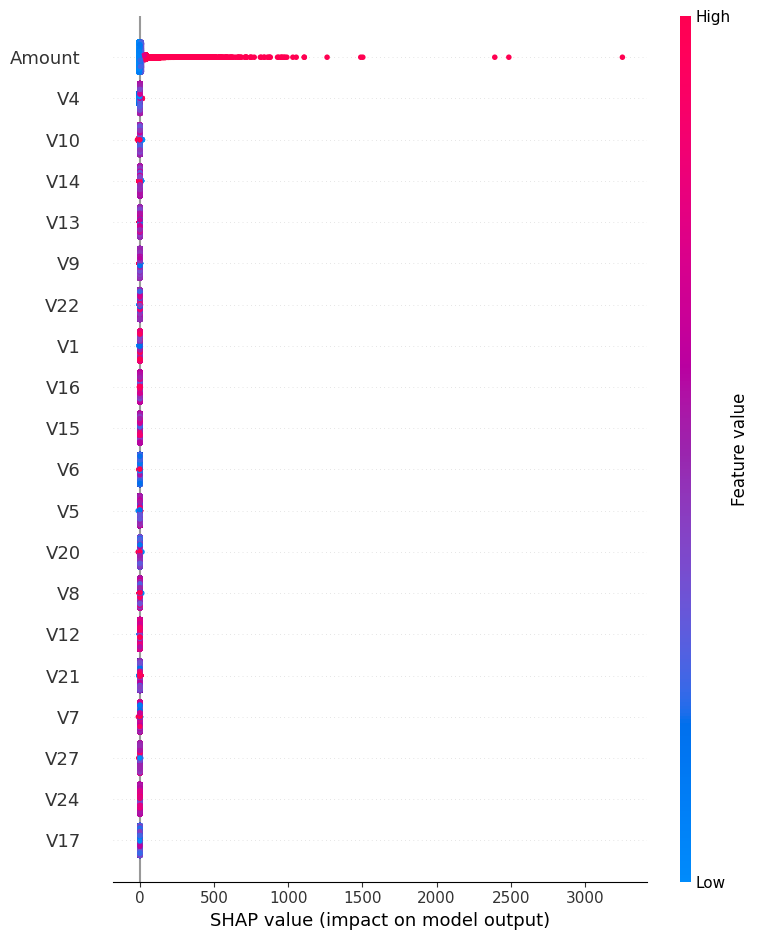

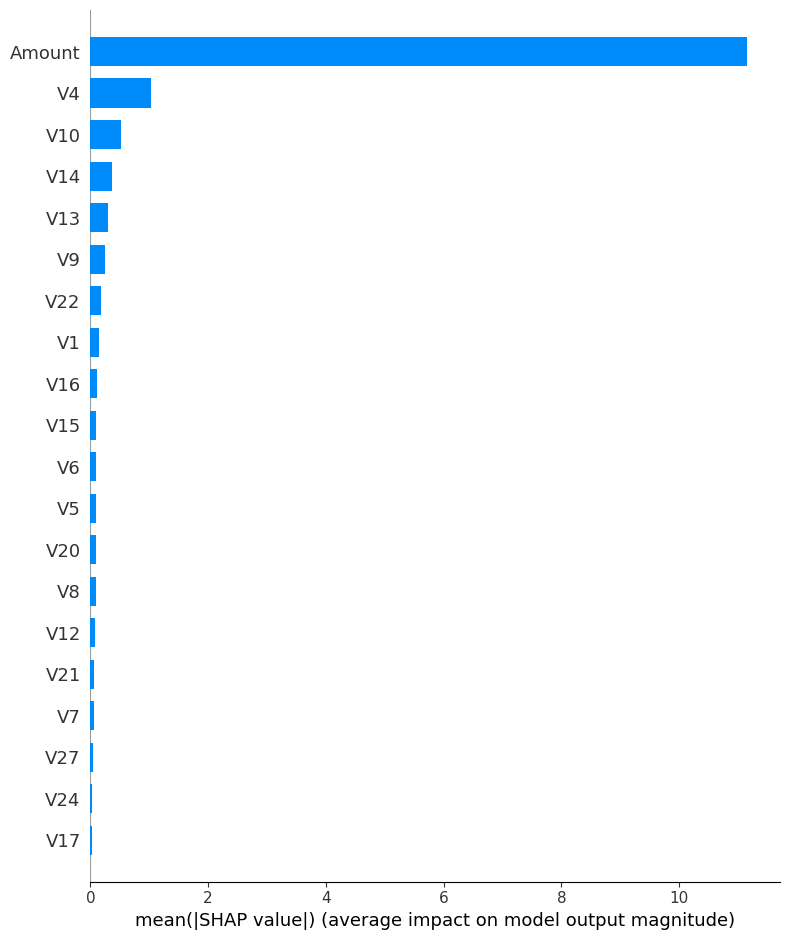

In [ ]:
interpretar_shap_lr(grid_search_lr_simples.best_estimator_, X)

##Modelagem com balanceamento no modelo

In [ ]:
grid_search_lr_bal = lr_train(LogisticRegression(class_weight='balanced'), param_grid_lr_simples, X_train_scaled_lr, y_lr_train)

In [ ]:
results_df_lr_bal = pd.DataFrame(grid_search_lr_bal.cv_results_)
results_df_lr_bal = results_df_lr_bal.sort_values(by=["rank_test_score"])
results_df_lr_bal = results_df_lr_bal.set_index(
    results_df_lr_bal["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df_lr_bal[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
0.1_l2_newton-cg,"{'C': 0.1, 'penalty': 'l2', 'solver': 'newton-...",1,-0.116568,0.002847
0.5_l2_newton-cg,"{'C': 0.5, 'penalty': 'l2', 'solver': 'newton-...",2,-0.116671,0.002550
0.1_l1_liblinear,"{'C': 0.1, 'penalty': 'l1', 'solver': 'libline...",3,-0.116693,0.002866
1_l2_newton-cg,"{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}",4,-0.116701,0.002472
0.5_l1_liblinear,"{'C': 0.5, 'penalty': 'l1', 'solver': 'libline...",5,-0.116714,0.002493
1_l1_liblinear,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",6,-0.116736,0.002456
5_l2_newton-cg,"{'C': 5, 'penalty': 'l2', 'solver': 'newton-cg'}",7,-0.116749,0.002433
0.5_l2_liblinear,"{'C': 0.5, 'penalty': 'l2', 'solver': 'libline...",8,-0.116751,0.002557
1_l2_liblinear,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",9,-0.116751,0.002487


In [ ]:
y_pred_lr_bal = grid_search_lr_bal.best_estimator_.predict_proba(X_test_scaled_lr)
print(f'Roc score: {roc_auc_score(y_lr_test, y_pred_lr_bal[:, 1])}')
print(f'Log Loss: {log_loss(y_lr_test, y_pred_lr_bal[:, 1])}')


Roc score: 0.9779775782223465
Log Loss: 0.11537439030079662


In [78]:
salvar(grid_search_lr_bal.best_estimator_, results_df_lr_bal.iloc[0]['params'], 'lr_balanced')

Modelo salvo com sucesso no arquivo lr_balanced.pkl


SHAP (Regressão Logística) calculado com sucesso.


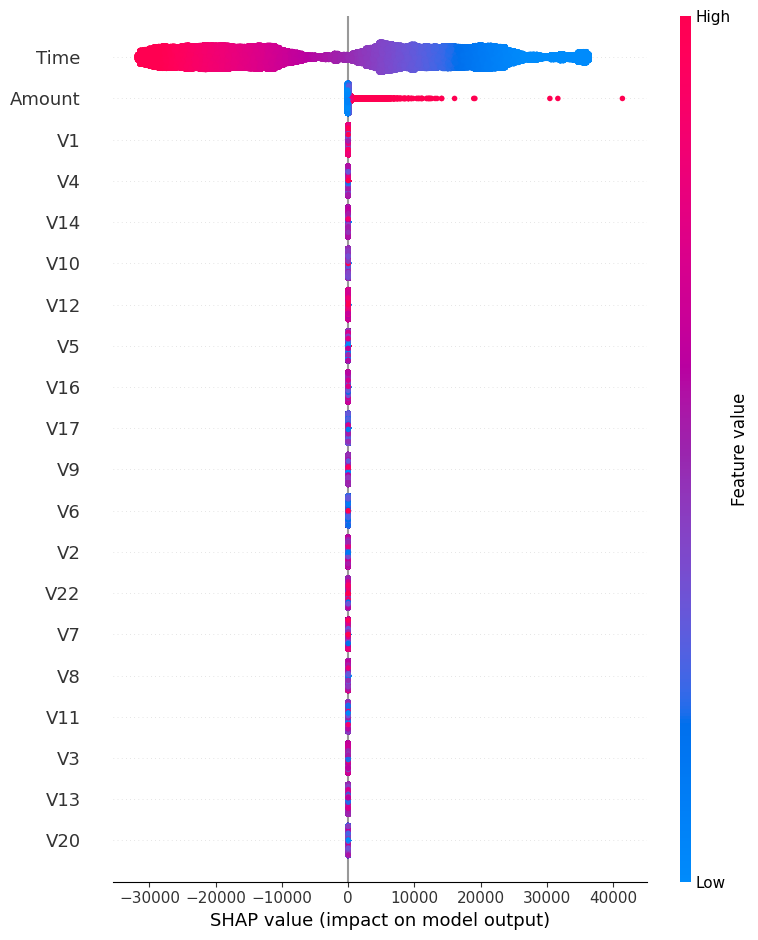

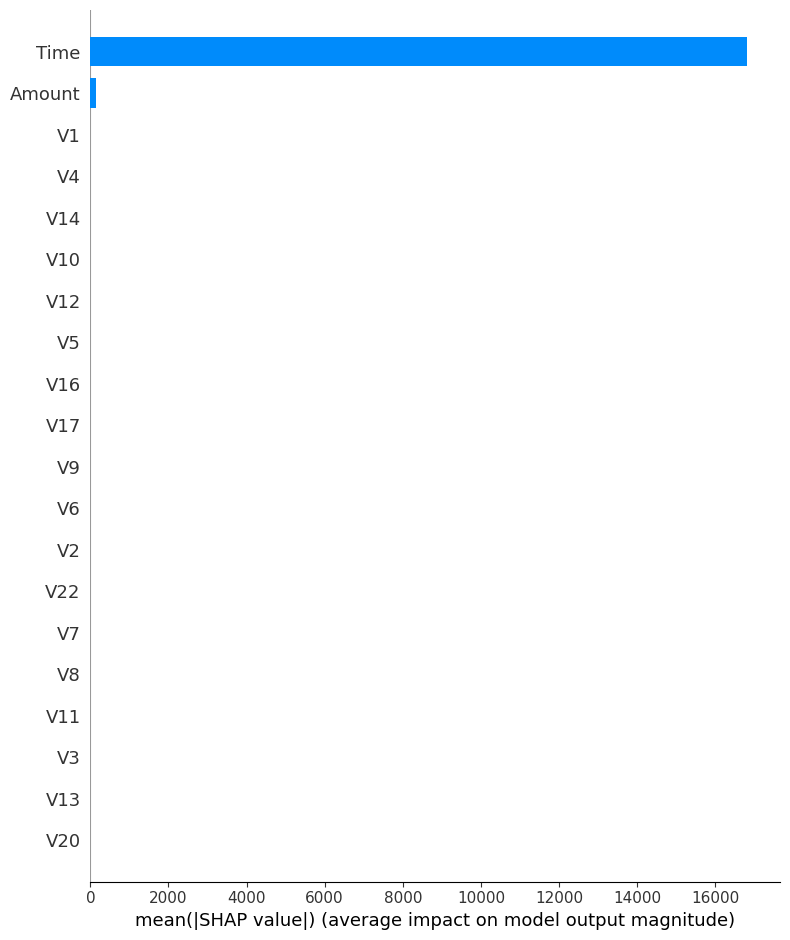

In [ ]:
interpretar_shap_lr(grid_search_lr_bal.best_estimator_, X)

##Modelagem com técnica de oversampling

In [ ]:
X_smote_scaled = scaler_lr.transform(X_smote)

In [ ]:
grid_search_lr_smote = lr_train(LogisticRegression(class_weight=None), param_grid_lr_simples, X_smote_scaled, y_smote)

In [ ]:
results_df_lr_smote = pd.DataFrame(grid_search_lr_smote.cv_results_)
results_df_lr_smote = results_df_lr_smote.sort_values(by=["rank_test_score"])
results_df_lr_smote = results_df_lr_smote.set_index(
    results_df_lr_smote["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df_lr_smote[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
5_l2_liblinear,"{'C': 5, 'penalty': 'l2', 'solver': 'liblinear'}",1,-0.072237,0.001214
5_None_newton-cg,"{'C': 5, 'penalty': None, 'solver': 'newton-cg'}",2,-0.072274,0.001219
0.5_None_newton-cg,"{'C': 0.5, 'penalty': None, 'solver': 'newton-...",2,-0.072274,0.001219
0.1_None_newton-cg,"{'C': 0.1, 'penalty': None, 'solver': 'newton-...",2,-0.072274,0.001219
1_None_newton-cg,"{'C': 1, 'penalty': None, 'solver': 'newton-cg'}",2,-0.072274,0.001219
5_l2_newton-cg,"{'C': 5, 'penalty': 'l2', 'solver': 'newton-cg'}",6,-0.072289,0.001219
1_l2_liblinear,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",7,-0.072331,0.001222
1_l2_newton-cg,"{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}",8,-0.072362,0.001220
0.5_l2_liblinear,"{'C': 0.5, 'penalty': 'l2', 'solver': 'libline...",9,-0.072433,0.001240


In [ ]:
y_pred_lr_smote = grid_search_lr_smote.best_estimator_.predict_proba(X_test_scaled_lr)
print(f'Roc score: {roc_auc_score(y_lr_test, y_pred_lr_smote[:, 1])}')
print(f'Log Loss: {log_loss(y_lr_test, y_pred_lr_smote[:, 1])}')


Roc score: 0.9764919858196446
Log Loss: 0.05992869540725345


In [79]:
salvar(grid_search_lr_smote.best_estimator_, results_df_lr_smote.iloc[0]['params'], 'lr_smote')

Modelo salvo com sucesso no arquivo lr_smote.pkl


SHAP (Regressão Logística) calculado com sucesso.


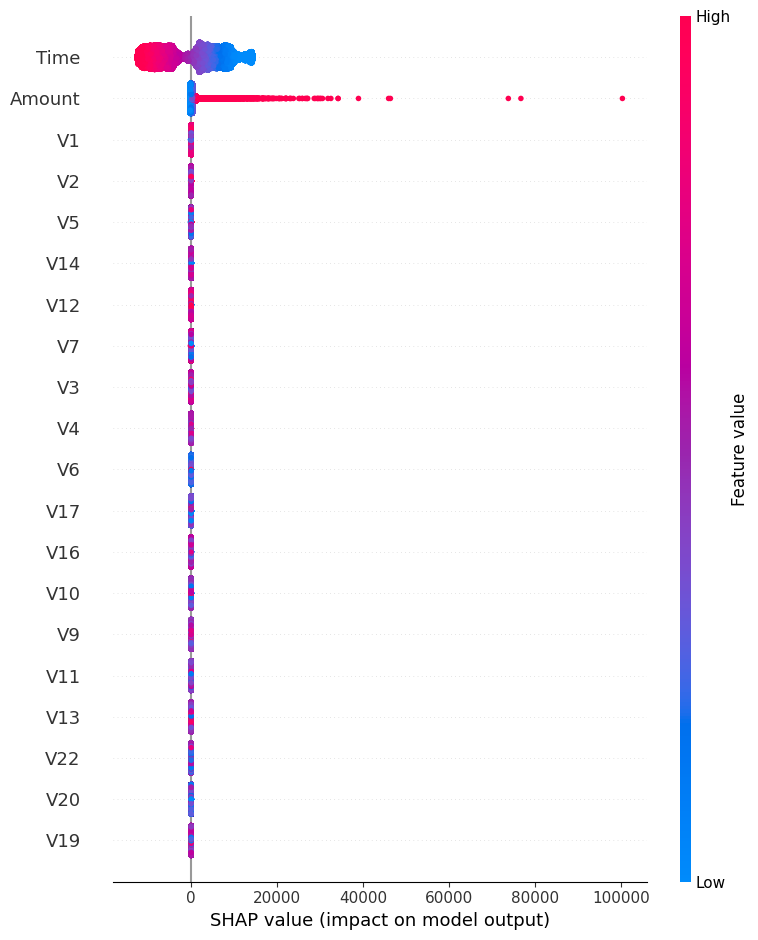

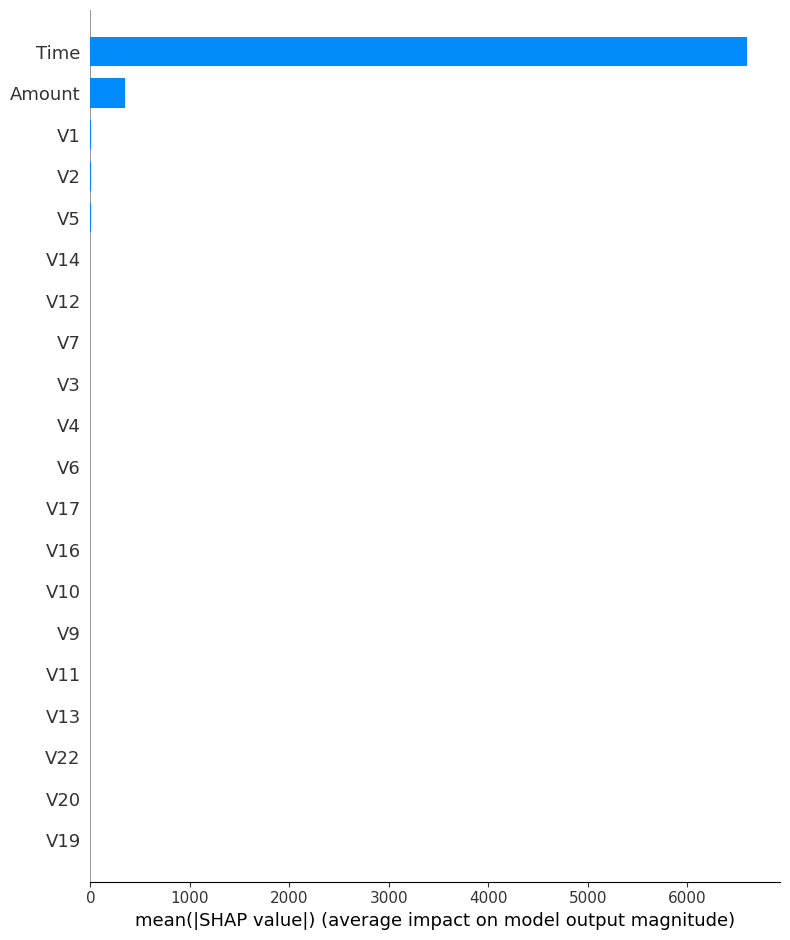

In [ ]:
interpretar_shap_lr(grid_search_lr_smote.best_estimator_, X)

##Conclusão

**Análise da Regressão Logística**

Após a modelagem, observa-se que o modelo de Regressão Logística demonstrou elevada sensibilidade à magnitude das variáveis explicativas. Esse comportamento é esperado, dado que se trata de um modelo linear cuja estimativa dos coeficientes está diretamente associada à escala das features.

Em praticamente todas as estratégias de modelagem avaliadas, as variáveis Amount e Time figuraram entre as mais influentes segundo as análises de importância (via SHAP e/ou magnitude dos coeficientes). A única exceção foi a modelagem simples sem tratamento de desbalanceamento; ainda assim, a variável Amount permaneceu como a mais relevante.Isso pode gera espaço para melhoria no quesito de retirar essas duas features que impactaram muito mais que as outras e testar se sem elas o modelo performar melhor ou não

**Interpretação das Variáveis Mais Influentes**:
 * **Amount**:A análise das contribuições individuais indica que valores elevados de Amount tendem a aumentar a probabilidade estimada de fraude. Em outras palavras, transações de maior valor monetário são interpretadas pelo modelo como mais propensas a serem fraudulentas. Esse comportamento é coerente com o contexto do problema, visto que fraudes frequentemente envolvem tentativas de maximizar o valor obtido antes da detecção.

* **Time**: Nos modelos em que Time apresentou relevância significativa, observou-se que valores mais altos dessa variável não estão, em geral, associados ao aumento da probabilidade de fraude. Isso sugere que o tempo decorrido (ou a posição temporal da transação na base) não possui relação linear direta com o evento fraudulento, podendo atuar mais como variável contextual do que como forte discriminante.

**Resultados do Modelo Selecionado**:

O melhor desempenho foi obtido pela: Regressão Logística com técnica de balanceamento interna ao modelo

**Métricas de Desempenho(Conjunto de teste)**:

* **ROC AUC**: 0.97798

* **Log Loss**: 0.11537

**Interpretação das Métricas**:
* **ROC AUC**: Indica excelente capacidade de discriminação entre transações fraudulentas e não fraudulentas. O modelo consegue separar adequadamente as classes ao longo de diferentes limiares de decisão.

* **Log Loss** = 0.115

Valor considerado baixo, sugerindo que as probabilidades previstas estão, em média, próximas dos rótulos reais. Isso indica boa qualidade probabilística e ausência de previsões excessivamente confiantes de forma sistemática.

#Random Forest

In [ ]:
X_train_rf = X_train
X_test_rf = X_test
y_train_rf = y_train
y_test_rf = y_test

##Funções Random Forest

In [ ]:
def interpretar_shap_rf(
    model,
    X,
    instance_index=None,
    plot_summary=True,
    plot_bar=True,
    plot_local=False
):

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    if len(shap_values.shape) == 3:
        shap_values = shap_values[:, :, 1]
        expected_value = explainer.expected_value[1]
    else:
        expected_value = explainer.expected_value

    print("SHAP (Random Forest) calculado com sucesso.")

    if plot_summary:
        shap.summary_plot(shap_values, X)

    if plot_bar:
        shap.summary_plot(shap_values, X, plot_type="bar")

    if plot_local and instance_index is not None:
        shap.initjs()
        shap.force_plot(
            expected_value,
            shap_values[instance_index],
            X.iloc[instance_index]
        )

##Modelagem simples

In [ ]:
param_grid_rf = {
    'max_depth': np.arange(2, 5, 1),
    'min_samples_split': np.arange(7, 12, 1),
    'min_samples_leaf': np.arange(5, 10, 1)
}


In [ ]:
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rf_simples = RandomForestClassifier(n_estimators=100)

In [ ]:
search_rf = RandomizedSearchCV(rf_simples, param_grid_rf, cv=5, scoring='neg_log_loss', n_iter=50, n_jobs=-1)

search_rf.fit(X_train_rf, y_train_rf)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': array([2, 3, 4]), 'min_samples_leaf': array([5, 6, 7, 8, 9]), 'min_samples_split': array([ 7, 8, 9, 10, 11])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versio

In [ ]:
results_df_rf = pd.DataFrame(search_rf.cv_results_)
results_df_rf = results_df_rf.sort_values(by=["rank_test_score"])
results_df_rf = results_df_rf.set_index(
    results_df_rf["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df_rf[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
9_6_4,"{'min_samples_split': 9, 'min_samples_leaf': 6...",1,-0.003695,0.000333
8_6_4,"{'min_samples_split': 8, 'min_samples_leaf': 6...",2,-0.003702,0.000357
11_5_4,"{'min_samples_split': 11, 'min_samples_leaf': ...",3,-0.003702,0.000336
10_5_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",4,-0.003715,0.000338
11_6_4,"{'min_samples_split': 11, 'min_samples_leaf': ...",5,-0.003728,0.000360
8_7_4,"{'min_samples_split': 8, 'min_samples_leaf': 7...",6,-0.003728,0.000406
10_6_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",7,-0.003730,0.000350
10_9_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",8,-0.003731,0.000355
10_7_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",9,-0.003731,0.000375


In [ ]:
y_pred_rf_simples = search_rf.best_estimator_.predict_proba(X_test_rf)[:, 1]
print(f'Roc score: {roc_auc_score(y_test_rf, y_pred_rf_simples)}')
print(f'Log Loss: {log_loss(y_test_rf, y_pred_rf_simples)}')


Roc score: 0.962144098596942
Log Loss: 0.0035442298331047335


In [80]:
salvar(search_rf.best_estimator_, results_df_rf.iloc[0]['params'], 'rf_simples')

Modelo salvo com sucesso no arquivo rf_simples.pkl


SHAP (Random Forest) calculado com sucesso.


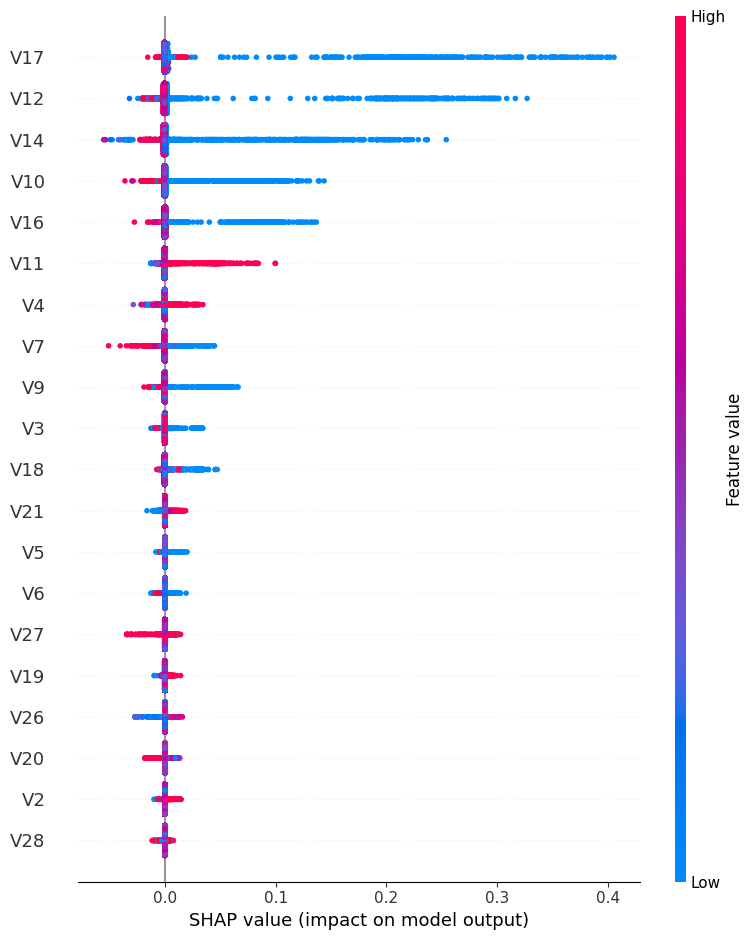

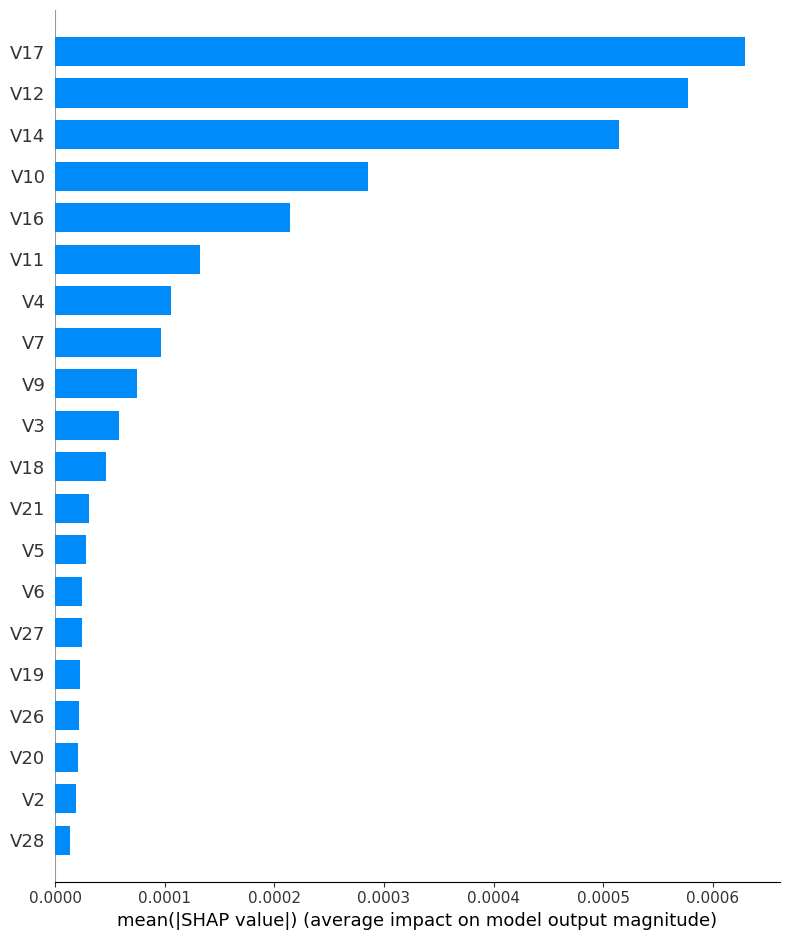

In [ ]:
interpretar_shap_rf(search_rf.best_estimator_, X)

##Modelagem com técnica de balanceamento do modelo

In [ ]:
search_rf_balanced = RandomizedSearchCV(rf_balanced, param_grid_rf, cv=5, scoring='neg_log_loss', n_iter=50, n_jobs=4)

search_rf_balanced.fit(X_train_rf, y_train_rf)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': array([2, 3, 4]), 'min_samples_leaf': array([5, 6, 7, 8, 9]), 'min_samples_split': array([ 7, 8, 9, 10, 11])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [ ]:
results_df_rf_balanced = pd.DataFrame(search_rf_balanced.cv_results_)
results_df_rf_balanced = results_df_rf_balanced.sort_values(by=["rank_test_score"])
results_df_rf_balanced = results_df_rf_balanced.set_index(
    results_df_rf_balanced["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df_rf_balanced[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
7_6_4,"{'min_samples_split': 7, 'min_samples_leaf': 6...",1,-0.091518,0.004703
7_5_4,"{'min_samples_split': 7, 'min_samples_leaf': 5...",2,-0.091630,0.004388
8_5_4,"{'min_samples_split': 8, 'min_samples_leaf': 5...",3,-0.091711,0.004321
11_8_4,"{'min_samples_split': 11, 'min_samples_leaf': ...",4,-0.092149,0.005024
9_9_4,"{'min_samples_split': 9, 'min_samples_leaf': 9...",5,-0.092579,0.002113
11_6_4,"{'min_samples_split': 11, 'min_samples_leaf': ...",6,-0.092793,0.004157
7_9_4,"{'min_samples_split': 7, 'min_samples_leaf': 9...",7,-0.093342,0.005660
9_8_4,"{'min_samples_split': 9, 'min_samples_leaf': 8...",8,-0.093510,0.003511
10_8_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",9,-0.093629,0.003799


In [ ]:
y_pred_rf_balanced = search_rf_balanced.best_estimator_.predict_proba(X_test_rf)[:, 1]
print(f'Roc score: {roc_auc_score(y_test_rf, y_pred_rf_balanced)}')
print(f'Log Loss: {log_loss(y_test_rf, y_pred_rf_balanced)}')


Roc score: 0.9837303647641252
Log Loss: 0.10318313782958535


In [81]:
salvar(search_rf_balanced.best_estimator_, results_df_rf_balanced.iloc[0]['params'], 'rf_balanced')

Modelo salvo com sucesso no arquivo rf_balanced.pkl


SHAP (Random Forest) calculado com sucesso.


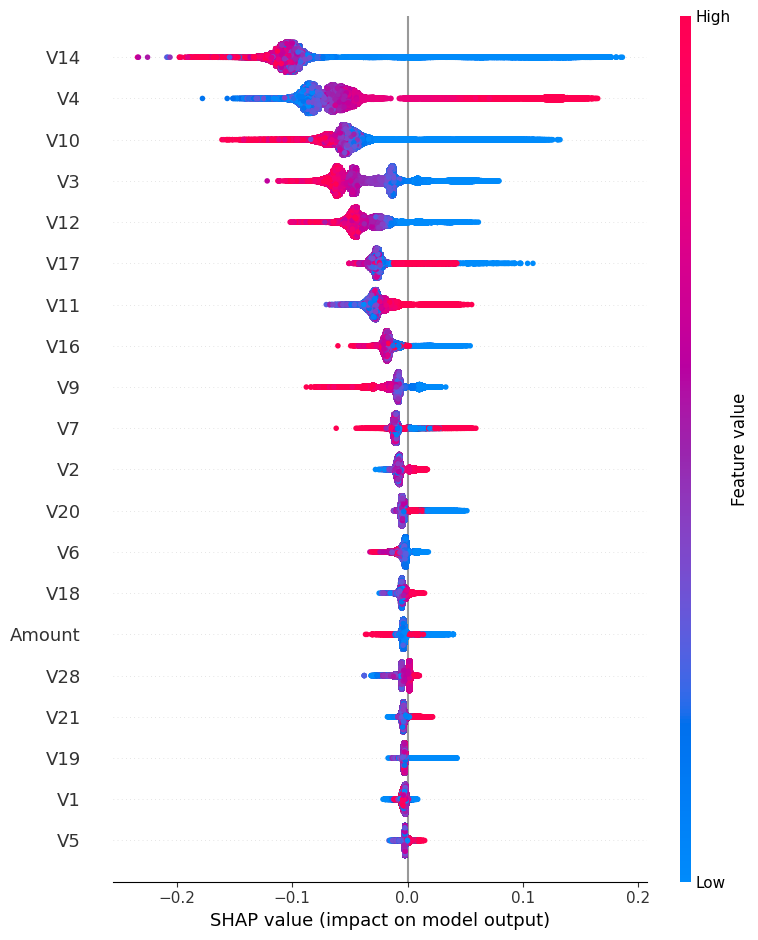

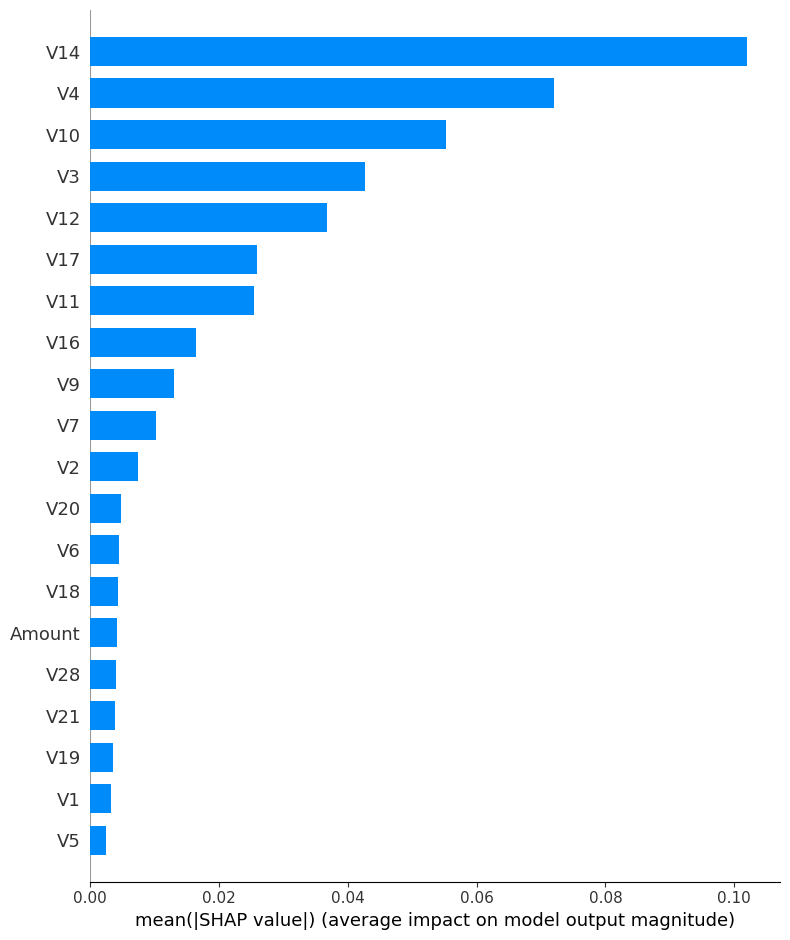

In [ ]:
interpretar_shap_rf(search_rf_balanced.best_estimator_, X)

##Modelagem com técnica de oversampling

In [ ]:
search_rf_smote = RandomizedSearchCV(rf_simples, param_grid_rf, cv=5, scoring='neg_log_loss', n_iter=50, n_jobs=4)

search_rf_smote.fit(X_smote, y_smote)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': array([2, 3, 4]), 'min_samples_leaf': array([5, 6, 7, 8, 9]), 'min_samples_split': array([ 7, 8, 9, 10, 11])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [ ]:
results_df_rf_smote = pd.DataFrame(search_rf_smote.cv_results_)
results_df_rf_smote = results_df_rf_smote.sort_values(by=["rank_test_score"])
results_df_rf_smote = results_df_rf_smote.set_index(
    results_df_rf_smote["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
).rename_axis("kernel")
results_df_rf_smote[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
7_5_4,"{'min_samples_split': 7, 'min_samples_leaf': 5...",1,-0.120508,0.001351
8_8_4,"{'min_samples_split': 8, 'min_samples_leaf': 8...",2,-0.121680,0.003473
7_9_4,"{'min_samples_split': 7, 'min_samples_leaf': 9...",3,-0.121818,0.001337
8_5_4,"{'min_samples_split': 8, 'min_samples_leaf': 5...",4,-0.122486,0.001790
9_6_4,"{'min_samples_split': 9, 'min_samples_leaf': 6...",5,-0.122560,0.003362
9_5_4,"{'min_samples_split': 9, 'min_samples_leaf': 5...",6,-0.122710,0.001252
9_9_4,"{'min_samples_split': 9, 'min_samples_leaf': 9...",7,-0.123066,0.003927
10_8_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",8,-0.123137,0.003526
10_9_4,"{'min_samples_split': 10, 'min_samples_leaf': ...",9,-0.123366,0.002859


In [ ]:
y_pred_rf_smote = search_rf_smote.best_estimator_.predict_proba(X_test_rf)[:, 1]
print(f'Roc score: {roc_auc_score(y_test_rf, y_pred_rf_smote)}')
print(f'Log Loss: {log_loss(y_test_rf, y_pred_rf_smote)}')


Roc score: 0.9821465442758084
Log Loss: 0.100485930177236


In [82]:
salvar(search_rf_smote.best_estimator_, results_df_rf_smote.iloc[0]['params'], 'rf_smote')

Modelo salvo com sucesso no arquivo rf_smote.pkl


SHAP (Random Forest) calculado com sucesso.


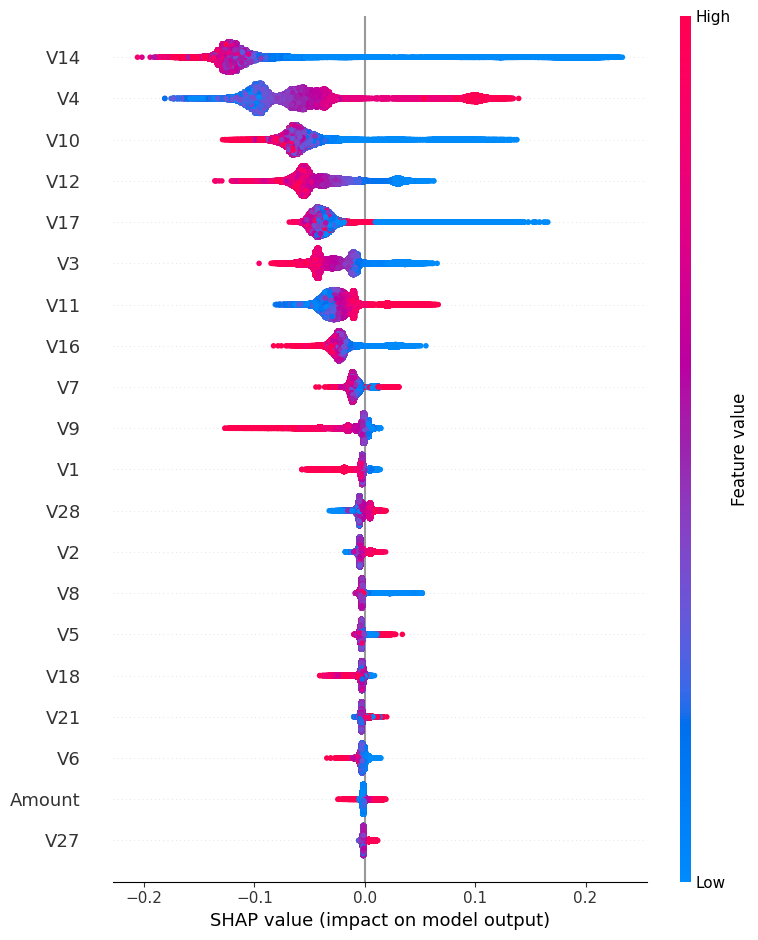

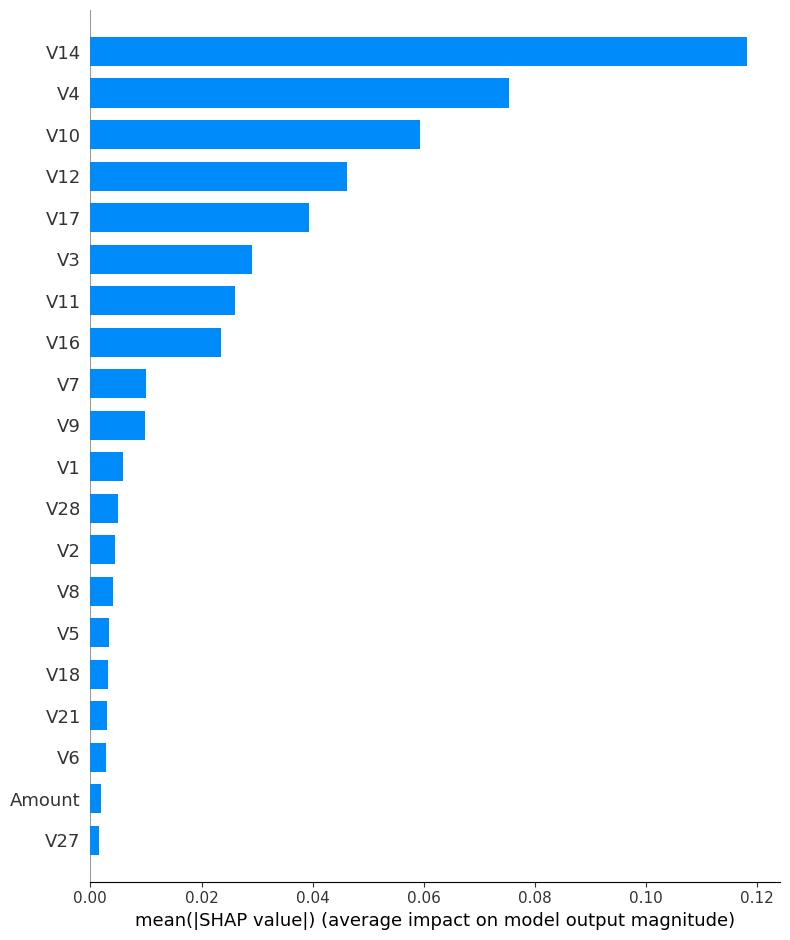

In [ ]:
interpretar_shap_rf(search_rf_smote.best_estimator_, X)

##Conclusão


**Interpretação dos valores SHAP**

A análise das explicações geradas pelo SHAP evidenciou diferenças relevantes entre os modelos que consideraram o desbalanceamento da base e o modelo treinado sem qualquer estratégia de balanceamento.

**Modelos com tratamento de desbalanceamento**

Os modelos que incorporaram técnicas para lidar com o desbalanceamento apresentaram:

* As três principais variáveis (Top 3 features) idênticas;

* A mesma ordem de importância para essas três variáveis;

* Alta consistência na hierarquia das variáveis mais relevantes.

* A partir da quarta posição, observou-se menor congruência entre as posições relativas das variáveis, embora as features mais influentes permanecessem semelhantes em magnitude.

**Esse comportamento indica**

Maior estabilidade estrutural do modelo;

Consistência na identificação dos principais fatores preditivos;

Redução da influência de ruído estatístico.


**Modelo sem tratamento de desbalanceamento**

O modelo treinado sem considerar o desbalanceamento apresentou:

* Maior variação na posição das variáveis mais importantes;

* Inclusão de variáveis com impacto médio muito próximo de zero;

Isso sugere:

* Maior sensibilidade à classe majoritária;

* Possível diluição do sinal das variáveis realmente discriminativas;

* Menor robustez na estrutura explicativa do modelo.

**Modelo Selecionado**

O melhor desempenho foi obtido pelo: Random Forest com técnica de balanceamento interna ao modelo

**Métricas de desempenho (Conjunto de teste)**

* ROC AUC: 0.9837

* Log Loss: 0.1032

**Interpretação das Métricas**
* **ROC AUC**: Indica excelente capacidade de separação entre as classes, evidenciando que o modelo consegue distinguir adequadamente instâncias positivas e negativas ao longo de diferentes limiares de decisão.

* **Log Loss**: Um valor relativamente baixo, indicando que as probabilidades previstas estão, em média, próximas dos rótulos verdadeiros. Isso sugere boa calibração probabilística e ausência de excesso de confiança sistemático nas previsões.